# Kredi Risk Analizi Projesi
---
### Veri Sözlüğü

| Değişken Adı | Açıklama | Veri Tipi |
| :--- | :--- | :--- |
| **SeriousDlqin2yrs** | Kişinin önümüzdeki 2 yıl içinde 90 gün veya daha fazla ödeme gecikmesine düşüp düşmediği (Hedef Değişken) | 0/1 ((Integer/Binary)) |
| **RevolvingUtilizationOfUnsecuredLines** | Kredi kartı ve kişisel kredi limitlerinin kullanım oranı (Gayrimenkul hariç) | Sayısal Oran |
| **age** | Borçlunun yaşı | Tam Sayı |
| **NumberOfTime30-59DaysPastDueNotWorse** | Son 2 yılda borcun 30-59 gün arası gecikme sayısı | Tam Sayı |
| **DebtRatio** | Aylık borç ödemeleri ve yaşam maliyetlerinin brüt gelire oranı | Sayısal Oran |
| **MonthlyIncome** | Aylık gelir | Gerçel Sayı |
| **NumberOfOpenCreditLinesAndLoans** | Açık olan kredi ve kredi kartı sayısı | Tam Sayı |
| **NumberOfTimes90DaysLate** | Borcun 90 gün veya daha fazla gecikme sayısı | Tam Sayı |
| **NumberRealEstateLoansOrLines** | Konut kredisi ve gayrimenkul bazlı kredi sayısı | Tam Sayı |
| **NumberOfTime60-89DaysPastDueNotWorse** | Son 2 yılda borcun 60-89 gün arası gecikme sayısı | Tam Sayı |
| **NumberOfDependents** | Ailedeki bakmakla yükümlü olunan kişi sayısı | Tam Sayı |

---

#### Proje Amacı ve Kapsamı
Bu projede müşterilerin demografik bilgileri ve geçmiş ödeme davranışları kullanılarak kredi temerrüt riski tahmin edilmektedir. Amaç, müşterinin önümüzdeki iki yıl içerisinde 90 gün veya daha fazla gecikmeye düşme olasılığını tahmin eden bir makine öğrenmesi modeli geliştirmektir.

#### İş Problemi
Bankaların kredi verme süreçlerinde riski minimize etmek ve sağlıklı bir kredi portföyü oluşturmak için otomatik karar destek sistemlerine ihtiyacı vardır.

**Hedef Değişken:** `SeriousDlqin2yrs`(Denetimli Öğrenme)

---------------------------------------------------------------------------------------------------------------------------------------------

#### BAŞARI KRİTERLERİ

Veri setindeki yaklaşık %6 riskli ve %94 güvenli müşteri dağılımı, belirgin bir sınıf dengesizliği (Class Imbalance) oluşturmaktadır. Bu nedenle yalnızca Accuracy (Doğruluk) metriğine odaklanmak yanıltıcı olabilir. Model performansı aşağıdaki metriklerle değerlendirilecektir.

**Ana Metrik:** ROC-AUC & Gini

Neden? ROC-AUC, modelin riskli müşterilere güvenli müşterilerden daha yüksek skor verme yeteneğini ölçerek karar eşiğinden bağımsız ayrıştırma performansını gösterir. Finansal risk modellemesinde kullanılan Gini katsayısı ise Gini = 2 × AUC − 1 formülüyle hesaplanarak takip edilecektir.

**Kritik Metrikler:** Recall & PR-AUC (Average Precision)

Neden? Recall, gerçekte riskli olan müşterilerin ne kadarının doğru tespit edildiğini gösterir. PR-AUC ise Precision–Recall ilişkisini özetleyerek sınıf dengesizliği bulunan veri setlerinde pozitif sınıf performansının değerlendirilmesini destekler. Bu çalışmada PR-AUC göstergesi olarak Average Precision (AP) kullanılacaktır.

**Dengeleyici Metrikler:** Precision & F1-Score

Neden? Precision, riskli olarak işaretlenen müşterilerin ne kadarının gerçekten riskli olduğunu gösterir. F1-Score ise Precision ve Recall'un harmonik ortalaması olarak riskli müşteri yakalama ile yanlış riskli işaretleme arasındaki dengenin izlenmesini sağlar.

**Karar Desteği:** Risk Skoru (Predict Proba)

Neden? Yalnızca 0/1 sınıflandırması yerine müşteriler için 0–1 aralığında tahmin skoru üretilmesi hedeflenmektedir. Bu skorlar, farklı karar eşikleri üzerinden müşterilerin risk düzeylerine göre değerlendirilmesine olanak sağlayacaktır.

In [1]:
# =============================================================================
# ADIM 0: KÜTÜPHANELERİN YÜKLENMESİ VE VERİYE ERİŞİM
# =============================================================================
import os
import gc
# Veri işleme
import numpy as np
import pandas as pd

# Görselleştirme
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_validate,
    StratifiedKFold,
    cross_val_predict
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    make_scorer,
    roc_auc_score,
    average_precision_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve
)

# İstatistik
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Gradient Boosting
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Veri yolunu tanımlıyoruz 
# Bu yapı projenin taşınabilir olmasını sağlar.
data_path = os.path.join('..', 'data', 'raw', 'cs-training.csv')

# Veriyi yüklüyoruz
# 'Unnamed: 0' sütunu Kaggle'dan gelen gereksiz bir indekstir, okurken düşürüyoruz.
df = pd.read_csv(data_path, index_col=0)

# Veri boyutunu ve başarılı yüklemeyi teyit edelim
print(f"Veri başarıyla yüklendi: {df.shape[0]} satır, {df.shape[1]} sütun")

# İlk bakış: Verinin ilk 5 satırı
df.head()

Veri başarıyla yüklendi: 150000 satır, 11 sütun


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


#### ==================================================
#### ADIM 1. BÖLÜM METODOLOJİK ÇERÇEVE VE MODEL GÜVENLİĞİ
#### ==================================================

**Veri Sızıntısını (Data Leakage) Önleme ve Doğrulama Stratejisi**

***Test Seti İzolasyonu:*** Veri seti %80 Train / %20 Test olarak ayrılacak; test seti sürecin en başında izole edilecektir.

***Türetim Kuralları:*** Keşifsel analizde kullanılan istatistikler yalnızca eğitim verisinden hesaplanacaktır. Modelleme aşamasında medyan gibi veriden öğrenilen değerler, Pipeline içerisinde her Cross-Validation katının eğitim bölümünden öğrenilecektir. Test setine yalnızca transform() uygulanacak, test verisi üzerinde fit() yapılmayacaktır.

***Doğrulama Tercihi:*** Verideki yaklaşık %6'lık sınıf dengesizliği nedeniyle, sabit bir validasyon seti yerine hedef sınıf oranını her katmanda koruyan 5-Fold Stratified Cross-Validation kullanılacaktır.

In [2]:
# =============================================================================
# ADIM 1: VERİNİN İZOLASYONU (TRAIN-TEST)
# =============================================================================

# 1. Ham veri henüz temizlenmeden %20 Test seti ayrılır.
# Hedef değişken oranı (stratify) her iki sette de korunur.
df_train, df_test = train_test_split(
    df, 
    test_size=0.20, 
    random_state=42, 
    stratify=df['SeriousDlqin2yrs']
)

# 2. İndeks uyuşmazlıklarını önlemek için indeksler sıfırlanır.
df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

# 3. Bellek yönetimi: Orijinal df silinerek yalnızca train verisiyle devam edilir.
del df
gc.collect()

# 4. Sınıf dağılım kontrolü
train_risk = df_train['SeriousDlqin2yrs'].mean() * 100
test_risk = df_test['SeriousDlqin2yrs'].mean() * 100

print(f"Train Seti: {df_train.shape[0]:,} satır | Temerrüt Oranı: %{train_risk:.2f}")
print(f"Test Seti : {df_test.shape[0]:,} satır | Temerrüt Oranı: %{test_risk:.2f}")

Train Seti: 120,000 satır | Temerrüt Oranı: %6.68
Test Seti : 30,000 satır | Temerrüt Oranı: %6.68


#### ANALİST NOTU:

Veri seti Eğitim ve Test olarak ayrılırken statik Hold-out yöntemi uygulanmış, random_state parametresiyle bölme işleminin tekrarlanabilirliği sağlanmıştır. Bu yaklaşım, deneysel süreçlerin tekrarlanabilirliğini ve model sürümlerinin tutarlı biçimde karşılaştırılmasını destekler.

***Stratify (Tabakalama):*** Verideki yaklaşık %6,7'lik sınıf dengesizliği dikkate alınarak hedef değişken oranının Eğitim ve Test setlerinde korunması sağlanmıştır.

**Üretim Ortamı (Production) Perspektifi**

Statik veri setlerinde random_state kullanımı tekrarlanabilirlik açısından uygun bir yaklaşımdır. Canlı veri akışının bulunduğu sistemlerde ise veri sızıntısı riskini azaltmak amacıyla Hash-ID tabanlı deterministik bölme; zamansal değişimlerin önemli olduğu kredi riski çalışmalarında ise Out-of-Time (OOT) doğrulama yaklaşımları değerlendirilebilir.

#### =========================
#### ADIM 2: VERİ SETİNE BAKIŞ 
#### =========================

Veri temizleme ve özellik mühendisliği adımlarına geçmeden önce değişken tiplerini, veri yapısını ve bellek kullanımını inceleyerek genel bir yol haritası oluşturuyoruz.

In [3]:
# =============================================================================
# ADIM 2.1: VERİ SÖZLÜĞÜ VE TİP KONTROLÜ
# =============================================================================

# Veri tipleri, eksik değer sayıları ve bellek kullanımının incelenmesi
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      120000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  120000 non-null  float64
 2   age                                   120000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  120000 non-null  int64  
 4   DebtRatio                             120000 non-null  float64
 5   MonthlyIncome                         96325 non-null   float64
 6   NumberOfOpenCreditLinesAndLoans       120000 non-null  int64  
 7   NumberOfTimes90DaysLate               120000 non-null  int64  
 8   NumberRealEstateLoansOrLines          120000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  120000 non-null  int64  
 10  NumberOfDependents                    116872 non-null  float64
dtype

#### ANALİST YORUMU: 

MonthlyIncome değişkeninde yaklaşık %20, NumberOfDependents değişkeninde ise yaklaşık %2.5 oranında eksik veri bulunmaktadır. 

Veri boyutu (10.1 MB) ve satır sayısı mevcut çalışma kapsamında bellek yönetimi açısından ek bir optimizasyon gerektirmediğinden, tip dönüştürme (downcasting) uygulanmayacaktır.

In [4]:
# ADIM 2.2: SAYISAL DEĞİŞKENLERİN İSTATİSTİKSEL ÖZETİ

display(df_train.describe().T)

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,120000.0,0.066842,0.249749,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,120000.0,6.128916,253.361490,0.0,0.029593,0.153318,0.557832,50708.0
age,120000.0,52.287842,14.771274,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,120000.0,0.420075,4.182138,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,120000.0,352.271245,2093.709509,0.0,0.175330,0.366194,0.860833,329664.0
MonthlyIncome,96325.0,6651.507345,14541.181413,0.0,3400.000000,5390.000000,8238.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,120000.0,8.465692,5.161693,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,120000.0,0.264942,4.158242,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,120000.0,1.018167,1.133055,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,120000.0,0.239858,4.144569,0.0,0.000000,0.000000,0.000000,98.0


#### ANALİST YORUMU:

NumberOfTime30-59DaysPastDueNotWorse ve diğer gecikme değişkenlerinde gözlenen maksimum 98 değerleri, değişkenlerin genel dağılımından belirgin şekilde ayrışmaktadır. Bu değerlerin frekansları ve değişkenler arasındaki ortak görülme yapısı incelenerek veri kalitesi açısından değerlendirilecektir.

RevolvingUtilizationOfUnsecuredLines değişkeninde 1'in üzerine çıkan değerler bulunmakla birlikte, maksimum 50.708 değeri dikkat çekmektedir. DebtRatio değişkeninde de benzer şekilde yüksek uç değerler gözlenmektedir. Bu değerlerin dağılımları sonraki aşamalarda ayrıntılı olarak incelenecektir.

age değişkeninde minimum değerin 0 olması dikkat çekmektedir. Bu gözlemlerin sayısı ve dağılımı incelenerek veri kalitesi açısından değerlendirilecektir.

DebtRatio, RevolvingUtilizationOfUnsecuredLines ve MonthlyIncome değişkenlerinde ortalamaya kıyasla yüksek standart sapmalar dikkat çekmektedir. Dağılım ve uç değer analizleri sonrasında gerekli görülmesi halinde dönüşüm veya ölçekleme yöntemleri değerlendirilecektir.

MonthlyIncome değişkenindeki minimum 0 değeri dikkat çekmektedir. Sıfır gelirli gözlemlerin sayısı ve hedef değişkenle ilişkisi incelenerek modelleme aşamasında nasıl ele alınacağı değerlendirilecektir.

NumberOfDependents değişkeninde gözlenen maksimum değerlerin (20) veri giriş hatası veya gerçek gözlem olup olmadığı incelenecektir.

Hedef değişkendeki (SeriousDlqin2yrs) riskli müşteri oranı yaklaşık %6,7 seviyesindedir. Sınıf dengesizliği nedeniyle model değerlendirmesinde Accuracy tek başına esas alınmayacak; AUC-ROC ve PR-AUC başta olmak üzere belirlenen performans metrikleri kullanılacaktır.

In [5]:
# =============================================================================
# ADIM 2.3: BENZERSİZ DEĞER SAYILARI
# =============================================================================

print(df_train.nunique().sort_values())

SeriousDlqin2yrs                             2
NumberOfTime60-89DaysPastDueNotWorse        13
NumberOfDependents                          13
NumberOfTime30-59DaysPastDueNotWorse        16
NumberOfTimes90DaysLate                     19
NumberRealEstateLoansOrLines                28
NumberOfOpenCreditLinesAndLoans             58
age                                         84
MonthlyIncome                            12678
DebtRatio                                93157
RevolvingUtilizationOfUnsecuredLines    100929
dtype: int64


#### ANALİST YORUMU:

Benzersiz değer sayıları, değişkenlerin yapısını ve çeşitliliğini incelemek amacıyla değerlendirilmiştir. 

SeriousDlqin2yrs değişkeninin 2 farklı değerle ikili hedef yapısında olduğu görülmektedir. 

Gecikme, kredi ve bağımlı kişi sayısını ifade eden değişkenler sınırlı sayıda benzersiz değer içerirken; MonthlyIncome, DebtRatio ve RevolvingUtilizationOfUnsecuredLines değişkenleri daha yüksek çeşitlilik göstermektedir.

#### =================================
#### 3. BÖLÜM: Veri Ön İşleme Adımları 
#### =================================

Bu bölümde grafiksel ve istatistiksel incelemeler ile ön işleme kararlarının belirlenmesi amacıyla df_train üzerinden oluşturulan df_work çalışma kopyası kullanılacaktır. Aykırı değer ve anomaliler, eksik veriler, özellik mühendisliği, değişkenler arası ilişkiler ve dağılım yapıları incelenerek modelleme için uygulanacak ön işleme stratejisi belirlenecektir.

Modelleme aşamasında veri sızıntısını (Data Leakage) önlemek amacıyla veriden parametre öğrenen işlemler doğrudan df_work üzerinden modele aktarılmayacak; Pipeline içerisinde her Cross-Validation katlamasının kendi eğitim verisinden öğrenilecektir.

**1. Outlier & Anomali Stratejisi:**

Veri setindeki aykırı ve uç değerler tespit edilecek; sistemsel hata olabilecek değerler ile gerçek ekstrem gözlemler ayrıştırılmaya çalışılacaktır. Gerekli görülmesi halinde, veri yapısına uygun sınırlandırma (clipping/winsorization) yöntemleri değerlendirilecektir.

**2. Eksik Veri (Missing Value) Stratejisi ve Doldurulması:**

Eksik veri kalıpları analiz edilerek eksikliğin bilgi taşıyıp taşımadığı değerlendirilecek; değişkenlerin yapısına uygun tamamlama (imputation) yöntemleri uygulanacaktır. Gerekli görülmesi halinde eksikliği temsil eden gösterge (flag) değişkenleri oluşturulacaktır.

**3. Özellik Mühendisliği (Feature Engineering):**

Müşterilerin finansal davranışlarını ve ödeme profillerini temsil edebilecek yeni oran ve etkileşim değişkenleri değerlendirilecektir.

**4. Kategorik Değişken Kodlama (Encoding Stratejisi):**

Özellik mühendisliği aşamasında kategorik, sıralı (ordinal) veya ikili (binary) değişkenler türetilmesi halinde, değişken yapısına ve model gereksinimlerine uygun kodlama yöntemleri değerlendirilecektir.

**5. Korelasyon Isı Haritası ve İlişki Analizi:**

Değişkenler arası doğrusal ilişkiler korelasyon matrisi üzerinden incelenerek yüksek bilgi örtüşmesi gösterebilecek öznitelikler tespit edilecektir. Bulgular sonraki özellik seçimi aşamasında IV ve VIF sonuçlarıyla birlikte değerlendirilecektir.

**6. Bilgi Kazancı ve Önem Analizi (Feature Selection):**

Değişkenlerin hedef sınıfı ayrıştırma gücü IV (Information Value) skorlarıyla incelenecektir. Düşük IV değerine sahip değişkenler doğrudan elenmek yerine, diğer analiz ve modelleme sonuçlarıyla birlikte değerlendirilerek özellik seçimine karar verilecektir.

**7. Multicollinearity (Çoklu Doğrusallık) Kontrolü ve Özellik Seçimi:**

Değişkenler arasındaki çoklu doğrusal bağlantı VIF analizi ile incelenecektir. Korelasyon, IV ve VIF bulguları birlikte değerlendirilerek modellemede kullanılacak özellik seti belirlenecektir.

**8. Dağılım Dönüşümleri ve Ölçekleme (Transformation & Scaling):**

Aşırı çarpıklık gösteren sürekli değişkenlerde gerekli görülmesi halinde uygun matematiksel dönüşümler değerlendirilecektir. Ölçekleme işlemleri ise kullanılan algoritmanın gereksinimine göre Pipeline içerisinde uygulanacaktır.


In [6]:
# =============================================================================
# ADIM 3.1: OUTLIER & ANOMALİ ANALİZİ
# =============================================================================

# Ham eğitim verisini koruyarak ön işleme için çalışma kopyası oluşturuyoruz.
df_work = df_train.copy()

#### Analiz İçeriği

- **3.1.1** Gecikme Değişkenleri
- **3.1.2** Age
- **3.1.3** Utilization
- **3.1.4** DebtRatio
- **3.1.5** MonthlyIncome
- **3.1.6** OpenCredit
- **3.1.7** RealEstate
- **3.1.8** Dependents

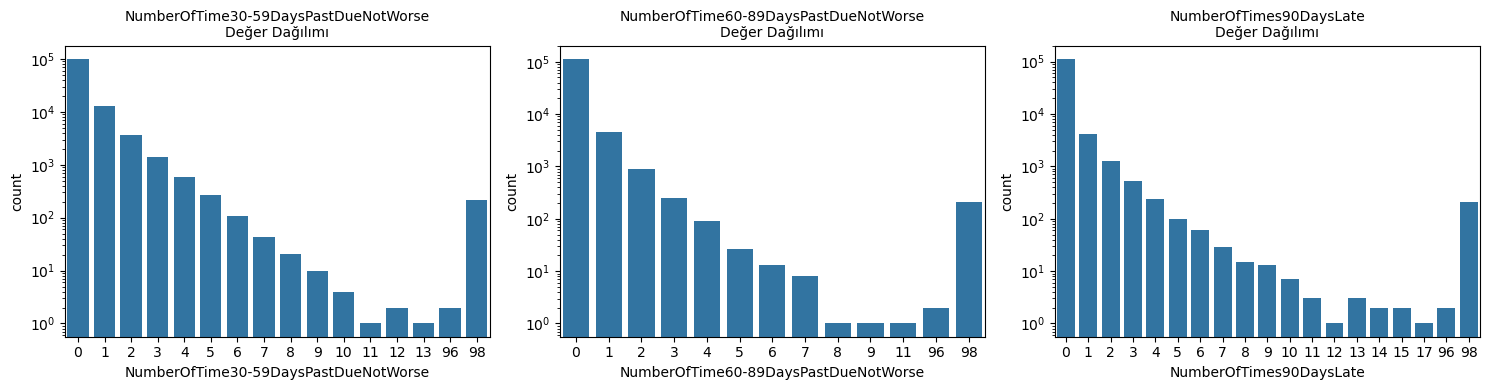

In [7]:
# =============================================================================
# ADIM 3.1.1: GECİKME DEĞİŞKENLERİ ANOMALİ ANALİZİ
# =============================================================================

late_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

# 1. Frekans Dağılımı Görselleştirmesi
plt.figure(figsize=(15, 4))

for i, col in enumerate(late_cols, 1):
    plt.subplot(1, 3, i)
    sns.countplot(x=df_work[col])
    plt.title(f'{col}\nDeğer Dağılımı', fontsize=10)
    plt.yscale('log')

plt.tight_layout()
plt.show()

In [8]:
# 2. 96/98 Değerlerinin Temerrüt Analizi
print("--- 96/98 Değerlerine Sahip Gözlemlerin Temerrüt Oranları ---")

for col in late_cols:
    anomaly_mask = df_work[col].isin([96, 98])

    anomaly_count = anomaly_mask.sum()
    default_rate = df_work.loc[anomaly_mask, 'SeriousDlqin2yrs'].mean() * 100

    print(
        f"{col}: {anomaly_count} gözlem "
        f"(%{anomaly_count / len(df_work) * 100:.2f}) | "
        f"Temerrüt Oranı: %{default_rate:.2f}"
    )

--- 96/98 Değerlerine Sahip Gözlemlerin Temerrüt Oranları ---
NumberOfTime30-59DaysPastDueNotWorse: 214 gözlem (%0.18) | Temerrüt Oranı: %54.67
NumberOfTime60-89DaysPastDueNotWorse: 214 gözlem (%0.18) | Temerrüt Oranı: %54.67
NumberOfTimes90DaysLate: 214 gözlem (%0.18) | Temerrüt Oranı: %54.67


#### ANALİST YORUMU

Gecikme değişkenlerinde (30-59, 60-89 ve 90+ gün) olağan dağılımdan belirgin şekilde ayrışan 96 ve 98 değerleri gözlenmiştir. Bu değerleri taşıyan gözlemlerin her üç değişkende de %54.67 temerrüt oranına sahip olması dikkat çekmektedir.

Her üç değişkende de 96/98 değerlerine sahip 214 gözlem bulunması nedeniyle, bu değerlerin aynı müşterilerde birlikte görülüp görülmediği incelenecektir. Bu kontrol sonrasında değerlerin yapısı ve uygulanabilecek ön işleme yaklaşımı değerlendirilecektir.

In [9]:
# =============================================================================
# ADIM 3.1.1.2: 96/98 DEĞERLERİNİN BİRLİKTE GÖRÜLME KONTROLÜ
# =============================================================================

anomaly_masks = {
    col: df_work[col].isin([96, 98])
    for col in late_cols
}

# Üç değişkende aynı anda 96/98 bulunan gözlemler
all_anomaly_mask = (anomaly_masks[late_cols[0]] & anomaly_masks[late_cols[1]] & anomaly_masks[late_cols[2]])

print(f"\nÜç değişkende ortak 96/98 gözlemi: {all_anomaly_mask.sum()}")

# Anomali gözlemlerindeki kombinasyonlar
display(df_work.loc[all_anomaly_mask, late_cols].value_counts().reset_index(name='Gözlem Sayısı'))


Üç değişkende ortak 96/98 gözlemi: 214


,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,Gözlem Sayısı
0,98,98,98,212
1,96,96,96,2


#### ANALİST YORUMU:

96 ve 98 değerlerine sahip 214 gözlemin tamamının üç gecikme değişkeninde eş zamanlı olarak yer aldığı görülmektedir. 

Gözlemlerin 212'sinde üç değişken de 98, 2'sinde ise üç değişken de 96 değerini almaktadır. 

,NumberOfTime30-59DaysPastDueNotWorse,Gozlem_Sayisi,Temerrut_Orani
0,0,100794,4.027025
1,1,12844,14.855185
2,2,3689,26.538357
3,3,1421,34.975369
4,4,581,43.545611
5,5,266,42.857143
6,6,108,52.777778
7,7,44,50.000000
8,8,21,28.571429
9,9,10,30.000000


,NumberOfTime60-89DaysPastDueNotWorse,Gozlem_Sayisi,Temerrut_Orani
0,0,113881,5.085133
1,1,4626,31.193256
2,2,883,48.924122
3,3,254,58.267717
4,4,91,62.637363
5,5,27,66.666667
6,6,13,76.923077
7,7,8,50.000000
8,8,1,0.000000
9,9,1,0.000000


,NumberOfTimes90DaysLate,Gozlem_Sayisi,Temerrut_Orani
0,0,113294,4.612777
1,1,4230,33.829787
2,2,1256,49.522293
3,3,530,58.113208
4,4,238,68.067227
5,5,100,64.000000
6,6,62,56.451613
7,7,29,75.862069
8,8,15,66.666667
9,9,13,92.307692


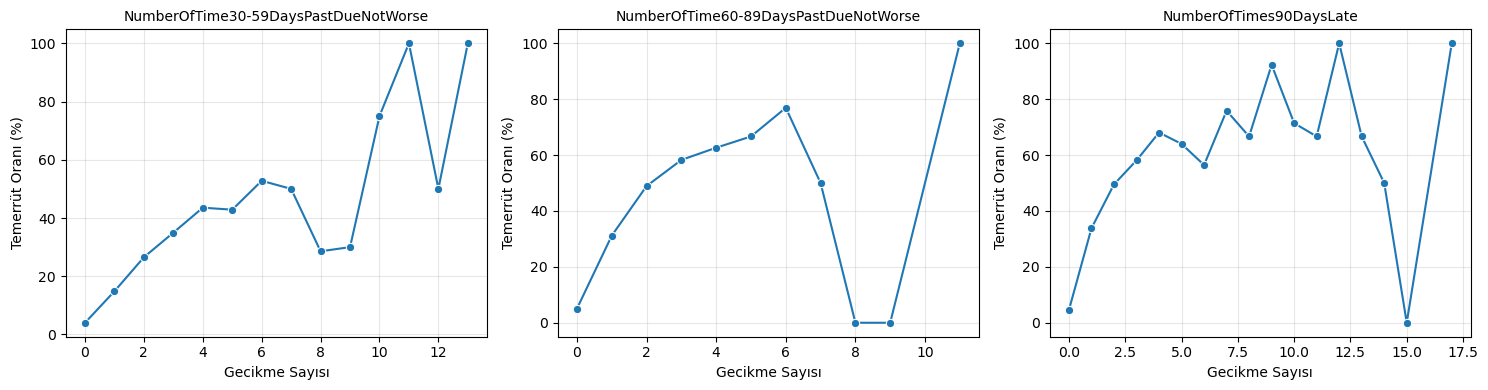

In [10]:
# =============================================================================
# ADIM 3.1.1.3: GECİKME SEVİYELERİNE GÖRE TEMERRÜT ORANI ANALİZİ
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(late_cols):
    
    # 96/98 anomalileri analiz dışında tutulur
    temp = df_work.loc[
        ~df_work[col].isin([96, 98]),
        [col, 'SeriousDlqin2yrs']
    ].copy()

    # Her gecikme seviyesi için gözlem sayısı ve temerrüt oranı
    risk_table = (
        temp.groupby(col)['SeriousDlqin2yrs']
        .agg(
            Gozlem_Sayisi='size',
            Temerrut_Orani='mean'
        )
        .reset_index()
    )

    risk_table['Temerrut_Orani'] *= 100

    # Sonuç tablosu
    display(risk_table)

    # Görselleştirme
    sns.lineplot(
        data=risk_table,
        x=col,
        y='Temerrut_Orani',
        marker='o',
        ax=axes[i]
    )

    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Gecikme Sayısı')
    axes[i].set_ylabel('Temerrüt Oranı (%)')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### ANALİST YORUMU

Gecikme sayısı arttıkça temerrüt oranının genel olarak yükseldiği görülmektedir. Yüksek gecikme seviyelerindeki dalgalanmalar düşük gözlem sayılarından kaynaklandığından, normal gecikme değerlerine clipping uygulanmayacaktır.

Önceki analizlerde 96/98 değerlerinin üç gecikme değişkeninde aynı 214 gözlemde birlikte görülmesi, bu değerlerin özel veya sistemsel bir durumu temsil edebileceğine işaret etmektedir. Bu nedenle ilgili gözlemler korunacak, 96/98 değerleri bir anomali göstergesiyle işaretlenecek ve gecikme değişkenlerindeki bu değerler medyanla ikame edilecektir. İkame değerleri modelleme aşamasında Pipeline içerisinde öğrenilecektir.

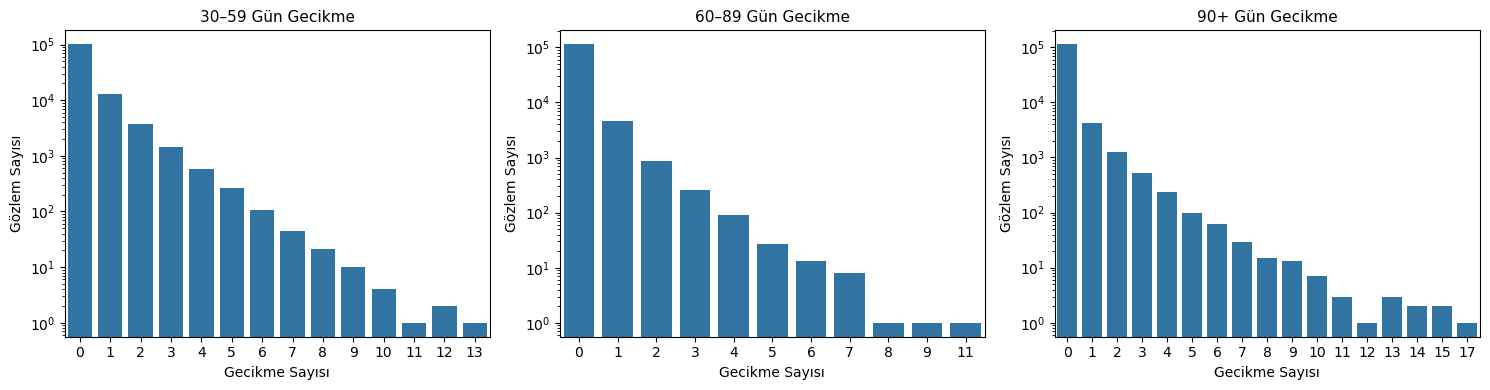

In [11]:
# =============================================================================
# ADIM 3.1.1.4: UYGULAMA - GECİKME ANOMALİLERİ
# =============================================================================

# Özel durum bilgisinin korunması
df_work['Is_Delay_Anomaly'] = (
    df_work[late_cols].isin([96, 98]).any(axis=1).astype('uint8')
)

# 96/98 değerlerini normal gözlemlerin medyanı ile ikame et
for col in late_cols:
    mask = df_work[col].isin([96, 98])
    median_val = df_work.loc[~mask, col].median()
    df_work.loc[mask, col] = median_val

# =============================================================================
# ADIM 3.1.1.5: GÖRSEL DOĞRULAMA
# =============================================================================

titles = ['30–59 Gün Gecikme', '60–89 Gün Gecikme', '90+ Gün Gecikme']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, title in zip(axes, late_cols, titles):
    sns.countplot(data=df_work, x=col, ax=ax)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Gecikme Sayısı')
    ax.set_ylabel('Gözlem Sayısı')
    ax.set_yscale('log')

plt.tight_layout()
plt.show()

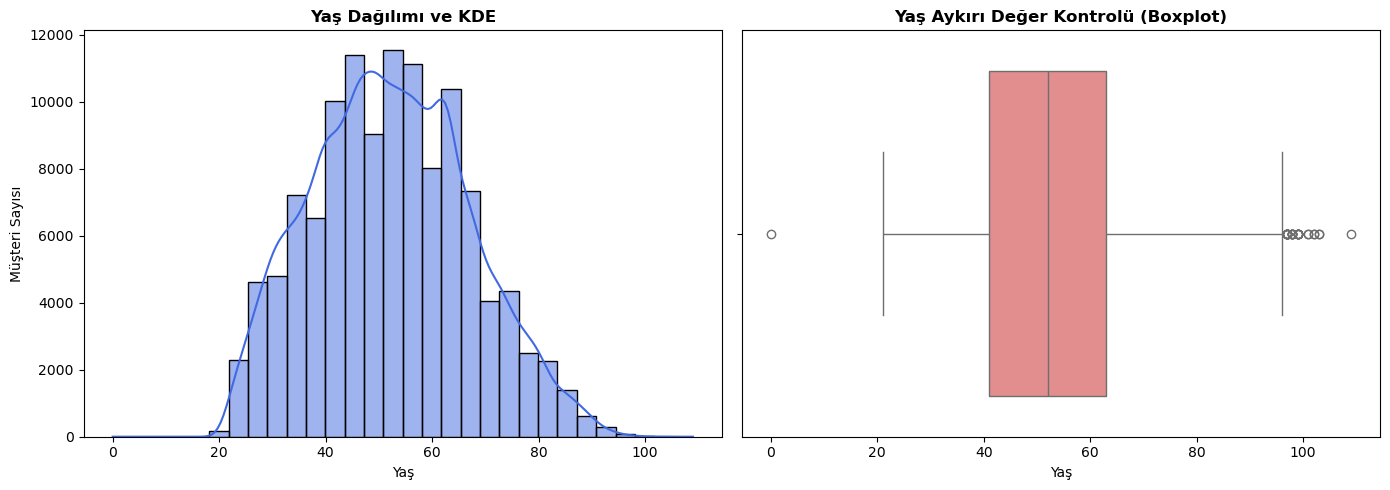

--- Yaş Değişkeni Metrikleri ---
Minimum Yaş      : 0
Maksimum Yaş     : 109
%99 Percentile   : 87
Yaş = 0          : 1


In [12]:
# =============================================================================
# ADIM 3.1.2 ANALİZ: YAŞ DEĞİŞKENİ ANOMALİ VE DAĞILIM İNCELEMESİ
# =============================================================================

plt.figure(figsize=(14, 5))

# 1. Histogram & KDE
plt.subplot(1, 2, 1)
sns.histplot(df_work['age'], kde=True, color='royalblue', bins=30, edgecolor='black')
plt.title('Yaş Dağılımı ve KDE', fontsize=12, fontweight='bold')
plt.xlabel('Yaş', fontsize=10)
plt.ylabel('Müşteri Sayısı', fontsize=10)

# 2. Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df_work['age'], color='lightcoral')
plt.title('Yaş Aykırı Değer Kontrolü (Boxplot)', fontsize=12, fontweight='bold')
plt.xlabel('Yaş', fontsize=10)

plt.tight_layout()
plt.show()

# İstatistiksel Sınır Kontrolleri
print("--- Yaş Değişkeni Metrikleri ---")
print(f"Minimum Yaş      : {df_work['age'].min()}")
print(f"Maksimum Yaş     : {df_work['age'].max()}")
print(f"%99 Percentile   : {df_work['age'].quantile(0.99):.0f}")
print(f"Yaş = 0          : {(df_work['age'] == 0).sum()}")

#### ANALİST YORUMU:

Yaş değişkeninde minimum 0, maksimum 109 ve %99 persentil 87 olarak gözlenmiştir. age = 0 mantıksal olarak geçersiz görünürken, üst yaş değerleri istatistiksel olarak uç olmakla birlikte doğrudan veri hatası olarak değerlendirilmeyecektir. Şüpheli yaş değerleri ayrıca incelenerek uygulanacak ön işleme yaklaşımına karar verilecektir.

In [13]:
# =============================================================================
# ADIM 3.1.2.1: İLERİ YAŞ DEĞERLERİNİN İNCELENMESİ
# =============================================================================

display(
    df_work.loc[df_work['age'] > 87]
    .groupby('age')['SeriousDlqin2yrs']
    .agg(Gozlem_Sayisi='size', Temerrut_Orani='mean')
    .reset_index()
)

,age,Gozlem_Sayisi,Temerrut_Orani
0,88,249,0.024096
1,89,221,0.027149
2,90,153,0.019608
3,91,123,0.024390
4,92,71,0.000000
5,93,68,0.000000
6,94,36,0.000000
7,95,36,0.027778
8,96,12,0.000000
9,97,16,0.000000


#### ANALİST YORUMU:

87 üzerindeki yaşlar P99 sınırına göre istatistiksel olarak uç değerlerdir. Ancak özellikle 88–95 yaş aralığında yeterli sayıda gözlem bulunması ve temerrüt oranlarının olağandışı bir yapı göstermemesi nedeniyle bu değerler veri hatası olarak değerlendirilmemiş ve üstten sınırlandırılmamıştır.

99 yaş ve üzerindeki gözlem sayıları oldukça düşük olduğundan bu seviyelerdeki temerrüt oranları tek başına anlamlı bir risk göstergesi olarak yorumlanmamıştır. 

age = 0 değeri ise mantıksal olarak geçersiz olduğundan medyan ile ikame edilecektir.

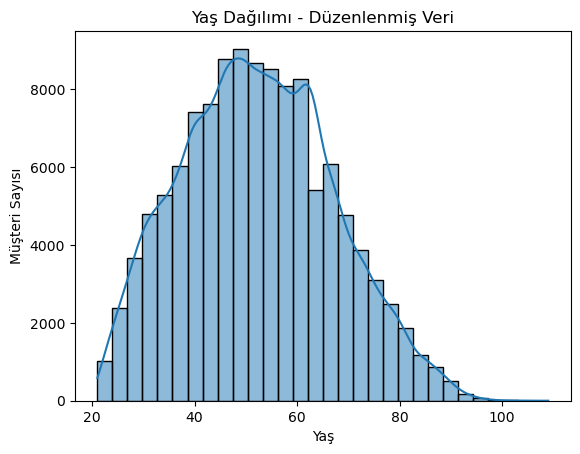

In [14]:
# =============================================================================
# ADIM 3.1.2.2: UYGULAMA - YAŞ ANOMALİSİ
# =============================================================================

# age=0 değerini normal yaş dağılımının medyanı ile ikame et
median_age = df_work.loc[df_work['age'] > 0, 'age'].median()
df_work.loc[df_work['age'] == 0, 'age'] = median_age

# =============================================================================
# ADIM 3.1.2.3: GÖRSEL DOĞRULAMA
# =============================================================================

sns.histplot(df_work['age'], kde=True, bins=30)
plt.title('Yaş Dağılımı - Düzenlenmiş Veri')
plt.xlabel('Yaş')
plt.ylabel('Müşteri Sayısı')
plt.show()

In [15]:
# =============================================================================
# ADIM 3.1.3 ANALİZ: KREDİ KULLANIM ORANI (UTILIZATION) ANOMALİ İNCELEMESİ
# =============================================================================

col = 'RevolvingUtilizationOfUnsecuredLines'

# 1. Sağ kuyruk yüzdeliklerinin incelenmesi
print("--- Sağ Kuyruk Yüzdelik Dağılımı ---")
display(df_work[col].quantile([0.50, 0.90, 0.95, 0.99, 0.999]))

# 2. 1.0 eşiğinin risk analizi
risk_analysis = (
    df_work
    .assign(Grup=np.where(df_work[col] > 1, '> 1.0', '<= 1.0'))
    .groupby('Grup')['SeriousDlqin2yrs']
    .agg(Gozlem_Sayisi='size', Temerrut_Orani='mean')
)

risk_analysis['Temerrut_Orani'] *= 100

print("\n--- Kredi Kullanım Oranı Eşik Analizi ---")
display(risk_analysis)

--- Sağ Kuyruk Yüzdelik Dağılımı ---


0.500       0.153318
0.900       0.980958
0.950       1.000000
0.990       1.094439
0.999    1655.004000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64


--- Kredi Kullanım Oranı Eşik Analizi ---


,Gozlem_Sayisi,Temerrut_Orani
Grup,,
<= 1.0,117360,5.990968
> 1.0,2640,37.500000


#### ANALİST YORUMU:

RevolvingUtilizationOfUnsecuredLines değişkeninde 1 üzerindeki gözlemlerin temerrüt oranı %37.50 iken, 1 ve altındaki gözlemlerde bu oran %5.99'dur. Bu nedenle 1 üzerindeki değerler önemli bir risk sinyali taşımaktadır. P99 sonrasında dağılımın belirgin şekilde genişlemesi nedeniyle üst kuyruk ayrıca incelenecektir.

In [16]:
# =============================================================================
# ADIM 3.1.3.1: KREDİ KULLANIM ORANI DETAYLI RİSK ANALİZİ
# =============================================================================

col = 'RevolvingUtilizationOfUnsecuredLines'

util_bins = [-np.inf, 1, 2, 5, 10, 100, 1000, np.inf]
util_labels = ['<=1', '1-2', '2-5', '5-10', '10-100', '100-1000', '>1000']

util_analysis = (
    df_work
    .assign(Grup=pd.cut(
        df_work[col],
        bins=util_bins,
        labels=util_labels
    ))
    .groupby('Grup', observed=True)['SeriousDlqin2yrs']
    .agg(Gozlem_Sayisi='size', Temerrut_Orani='mean')
)

util_analysis['Temerrut_Orani'] *= 100

print("--- Kredi Kullanım Oranı Detaylı Risk Analizi ---")
display(util_analysis)

--- Kredi Kullanım Oranı Detaylı Risk Analizi ---


,Gozlem_Sayisi,Temerrut_Orani
Grup,,
<=1,117360,5.990968
1-2,2348,40.119250
2-5,93,31.182796
5-10,9,22.222222
10-100,18,33.333333
100-1000,33,3.030303
>1000,139,7.194245


#### ANALİST YORUMU:

Kredi kullanım oranı 1'in üzerine çıktığında temerrüt oranı belirgin şekilde yükselmektedir. 1-2 aralığında temerrüt oranı %40.12, 2-5 aralığında %31.18'dir. Çok yüksek değerlerde risk ilişkisinin farklılaşması nedeniyle aşırı değerler ayrıca incelenecektir.

In [17]:
# =============================================================================
# ADIM 3.1.3.2: KREDİ KULLANIM ORANI AŞIRI DEĞER KONTROLÜ
# =============================================================================

col = 'RevolvingUtilizationOfUnsecuredLines'

# Utilization > 10 gözlemlerini özetle
extreme_util = df_work[df_work[col] > 10]

print(f"Gözlem Sayısı   : {len(extreme_util)}")
print(f"Temerrüt Oranı : %{extreme_util['SeriousDlqin2yrs'].mean() * 100:.2f}")
print(f"Medyan          : {extreme_util[col].median():.2f}")
print(f"Minimum         : {extreme_util[col].min():.2f}")
print(f"Maksimum        : {extreme_util[col].max():.2f}")

# En sık görülen aşırı değerler
print("\n--- En Sık Görülen Değerler ---")
display(
    extreme_util[col]
    .value_counts()
    .head(15)
    .rename_axis('Utilization')
    .reset_index(name='Gozlem_Sayisi')
)

Gözlem Sayısı   : 190
Temerrüt Oranı : %8.95
Medyan          : 2047.00
Minimum         : 11.39
Maksimum        : 50708.00

--- En Sık Görülen Değerler ---


,Utilization,Gozlem_Sayisi
0,2128.0,2
1,50.0,2
2,638.0,2
3,601.0,1
4,3593.0,1
5,2066.0,1
6,4086.0,1
7,4133.0,1
8,356.0,1
9,3081.0,1


#### ANALİST YORUMU

Kredi kullanım oranında 1’in üzerindeki değerler belirgin bir risk artışı göstermektedir. Ancak aşırı yüksek değerlerde bu ilişki bozulmakta; Utilization > 10 grubunda 190 gözlem bulunurken medyan değer 2.047 ve temerrüt oranı %8.95 seviyesinde kalmaktadır.

Bu değerlerin normal kullanım oranı ölçeğini temsil etmediği değerlendirildiğinden, >10 değerleri anomali olarak işaretlenecek, anomali bilgisi ayrı bir flag ile korunacak ve ilgili değerler normal gözlemlerin medyanı ile ikame edilecektir.

Anomali Sayısı : 190
İkame Medyanı  : 0.1524
Yeni Maksimum  : 7.31


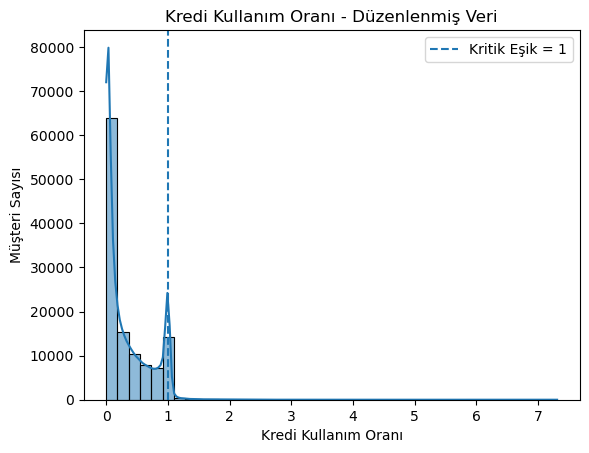

In [18]:
# =============================================================================
# ADIM 3.1.3.3: UYGULAMA - KREDİ KULLANIM ORANI ANOMALİSİ
# =============================================================================

col = 'RevolvingUtilizationOfUnsecuredLines'

# Aşırı değerleri işaretle
df_work['Is_Utilization_Anomaly'] = (df_work[col] > 10).astype('uint8')

# Aşırı değerleri normal gözlemlerin medyanı ile ikame et
median_util = df_work.loc[df_work[col] <= 10, col].median()
df_work.loc[df_work[col] > 10, col] = median_util

print(f"Anomali Sayısı : {df_work['Is_Utilization_Anomaly'].sum()}")
print(f"İkame Medyanı  : {median_util:.4f}")
print(f"Yeni Maksimum  : {df_work[col].max():.2f}")


# =============================================================================
# ADIM 3.1.3.4: GÖRSEL DOĞRULAMA
# =============================================================================

sns.histplot(df_work[col], bins=40, kde=True)
plt.axvline(1, linestyle='--', label='Kritik Eşik = 1')
plt.title('Kredi Kullanım Oranı - Düzenlenmiş Veri')
plt.xlabel('Kredi Kullanım Oranı')
plt.ylabel('Müşteri Sayısı')
plt.legend()
plt.show()

#### ANALİST YORUMU

Utilization > 10 olan 190 anomali gözlem medyan ile ikame edilmiş ve anomali bilgisi ayrı bir flag değişkeninde korunmuştur. Düzenleme sonrasında aşırı uç değerler giderilirken, 1 üzerindeki yüksek risk sinyali taşıyan gözlemler korunmuştur.

In [19]:
# =============================================================================
# ADIM 3.1.4 ANALİZ: BORÇ ORANI (DEBTRATIO) ANOMALİ İNCELEMESİ
# =============================================================================

col = 'DebtRatio'

# 1. Temel dağılım ve sağ kuyruk yüzdelikleri
print("--- DebtRatio Dağılım Özeti ---")
print(f"Minimum  : {df_work[col].min():.4f}")
print(f"Maksimum : {df_work[col].max():.2f}")

display(
    df_work[col].quantile([0.50, 0.90, 0.95, 0.99, 0.999])
)

# 2. DebtRatio > 1 risk analizi
risk_analysis = (
    df_work
    .assign(Grup=np.where(df_work[col] > 1, '> 1.0', '<= 1.0'))
    .groupby('Grup')['SeriousDlqin2yrs']
    .agg(Gozlem_Sayisi='size', Temerrut_Orani='mean')
)

risk_analysis['Temerrut_Orani'] *= 100

print("\n--- DebtRatio Eşik Analizi ---")
display(risk_analysis)

--- DebtRatio Dağılım Özeti ---
Minimum  : 0.0000
Maksimum : 329664.00


0.500        0.366194
0.900     1263.000000
0.950     2441.000000
0.990     4977.000000
0.999    10613.074000
Name: DebtRatio, dtype: float64


--- DebtRatio Eşik Analizi ---


,Gozlem_Sayisi,Temerrut_Orani
Grup,,
<= 1.0,92013,6.759914
> 1.0,27987,6.435131


#### ANALİST YORUMU 

DebtRatio değişkeni belirgin şekilde sağa çarpık bir dağılıma ve yüksek uç değerlere sahiptir. Ancak 1 üzerindeki değerlerde temerrüt oranının belirgin şekilde artmaması, yüksek değerlerin doğrudan yüksek risk olarak yorumlanamayacağını göstermektedir. Bu nedenle uç değerlere müdahale edilmeden önce dağılım ve gelir eksikliği ile ilişkisi detaylı olarak incelenecektir.

In [20]:
# =============================================================================
# ADIM 3.1.4.1: BORÇ ORANI (DEBTRATIO) RİSK ANALİZİ
# =============================================================================

col = 'DebtRatio'

debt_bins = [-np.inf, 0.5, 1, 10, 100, 1000, 5000, np.inf]
debt_labels = ['<=0.5', '0.5-1', '1-10', '10-100',
               '100-1000', '1000-5000', '>5000']

debt_analysis = (
    df_work
    .assign(Grup=pd.cut(df_work[col], bins=debt_bins, labels=debt_labels))
    .groupby('Grup', observed=True)['SeriousDlqin2yrs']
    .agg(Gozlem_Sayisi='size', Temerrut_Orani='mean')
)

debt_analysis['Temerrut_Orani'] *= 100

print("--- DebtRatio Detaylı Risk Analizi ---")
display(debt_analysis)

--- DebtRatio Detaylı Risk Analizi ---


,Gozlem_Sayisi,Temerrut_Orani
Grup,,
<=0.5,75036,6.054427
0.5-1,16977,9.878070
1-10,4968,10.789050
10-100,3575,4.223776
100-1000,5949,7.631535
1000-5000,12312,4.686485
>5000,1183,7.016061


#### ANALİST YORUMU

DebtRatio değişkeninde temerrüt oranı 1–10 aralığında %10.79 ile en yüksek seviyeye ulaşırken, daha yüksek değerlerde düzenli bir risk artışı görülmemektedir. Bu durum yüksek DebtRatio değerlerinin tek başına yüksek risk göstergesi olarak değerlendirilemeyeceğini ve farklı bir veri yapısını temsil edebileceğini göstermektedir.

In [21]:
# =============================================================================
# ADIM 3.1.4.2: DEBTRATIO - GELİR EKSİKLİĞİ VE RİSK İLİŞKİSİ
# =============================================================================

income_check = (
    df_work
    .assign(Gelir_Eksik=df_work['MonthlyIncome'].isna())
    .groupby('Gelir_Eksik')
    .agg(
        Gozlem_Sayisi=('DebtRatio', 'size'),
        DebtRatio_Medyan=('DebtRatio', 'median'),
        DebtRatio_Ortalama=('DebtRatio', 'mean'),
        DebtRatio_Maksimum=('DebtRatio', 'max'),
        Temerrut_Orani=('SeriousDlqin2yrs', 'mean')
    )
)

income_check['Temerrut_Orani'] *= 100

print("--- DebtRatio / Gelir Eksikliği ve Risk İlişkisi ---")
display(income_check)

--- DebtRatio / Gelir Eksikliği ve Risk İlişkisi ---


,Gozlem_Sayisi,DebtRatio_Medyan,DebtRatio_Ortalama,DebtRatio_Maksimum,Temerrut_Orani
Gelir_Eksik,,,,,
False,96325,0.296108,25.424535,25801.0,6.957695
True,23675,1163.000000,1682.092122,329664.0,5.571278


#### ANALİST YORUMU 

DebtRatio, gelir eksikliğine göre belirgin şekilde farklılaşmaktadır. MonthlyIncome mevcut olan müşterilerde medyan DebtRatio 0.30 ve temerrüt oranı %6.96 iken, geliri eksik müşterilerde medyan 1163 olmasına rağmen temerrüt oranı %5.57'dir. Bu nedenle yüksek DebtRatio değerleri doğrudan yüksek risk veya anomali olarak değerlendirilmeyecek, gelir eksikliğiyle ilişkili farklı veri yapısı olarak ele alınacaktır.

In [22]:
# =============================================================================
# ADIM 3.1.4.3: UYGULAMA - DEBTRATIO
# =============================================================================

# Gelir eksikliği bilgisini koru
df_work['Is_Income_Missing'] = df_work['MonthlyIncome'].isna().astype('uint8')

print(f"Gelir Eksik Gözlem : {df_work['Is_Income_Missing'].sum()}")
print(f"DebtRatio Aralığı   : {df_work['DebtRatio'].min():.2f} - {df_work['DebtRatio'].max():.2f}")

Gelir Eksik Gözlem : 23675
DebtRatio Aralığı   : 0.00 - 329664.00


#### ANALİST YORUMU 

DebtRatio'daki yüksek değerlerin gelir eksikliğiyle ilişkili farklı bir veri yapısı gösterdiği görüldüğünden clipping veya ikame uygulanmamıştır. Gelir eksikliği bilgisi Is_Income_Missing flag'i ile korunmuş, dağılımsal dönüşüm ihtiyacı ise dönüşüm aşamasında ayrıca ele alınacaktır.

In [23]:
# =============================================================================
# ADIM 3.1.5 ANALİZ: AYLIK GELİR (MONTHLYINCOME) ANOMALİ VE DAĞILIM İNCELEMESİ
# =============================================================================

col = 'MonthlyIncome'

print("--- MonthlyIncome Dağılım Özeti ---")
print(f"Eksik Gözlem : {df_work[col].isna().sum():,}")
print(f"Eksik Oranı  : %{df_work[col].isna().mean() * 100:.2f}")
print(f"Minimum      : {df_work[col].min():.2f}")
print(f"Maksimum     : {df_work[col].max():.2f}")

display(
    df_work[col].quantile([0.50, 0.90, 0.95, 0.99, 0.999])
)

--- MonthlyIncome Dağılım Özeti ---
Eksik Gözlem : 23,675
Eksik Oranı  : %19.73
Minimum      : 0.00
Maksimum     : 3008750.00


0.500     5390.000
0.900    11640.600
0.950    14584.800
0.990    25000.000
0.999    77764.776
Name: MonthlyIncome, dtype: float64

#### ANALİST YORUMU

MonthlyIncome değişkeninde yaklaşık %20 oranında eksik veri bulunmakta ve dağılımın üst kuyruğunda yüksek gelir değerleri görülmektedir.

In [24]:
# =============================================================================
# ADIM 3.1.5.1: AYLIK GELİR DETAYLI RİSK ANALİZİ
# =============================================================================

income_bins = [-np.inf, 0, 2500, 5000, 10000, 25000, 50000, 100000, np.inf]
income_labels = [
    '0', '0-2.5K', '2.5K-5K', '5K-10K',
    '10K-25K', '25K-50K', '50K-100K', '>100K'
]

income_analysis = (
    df_work
    .dropna(subset=['MonthlyIncome'])
    .assign(Grup=lambda x: pd.cut(
        x['MonthlyIncome'],
        bins=income_bins,
        labels=income_labels,
        include_lowest=True
    ))
    .groupby('Grup', observed=True)['SeriousDlqin2yrs']
    .agg(Gozlem_Sayisi='size', Temerrut_Orani='mean')
)

income_analysis['Temerrut_Orani'] *= 100

display(income_analysis)

,Gozlem_Sayisi,Temerrut_Orani
Grup,,
0,1322,4.160363
0-2.5K,13279,9.021764
2.5K-5K,30266,8.587194
5K-10K,36839,6.015364
10K-25K,13698,4.263396
25K-50K,681,5.139501
50K-100K,188,6.382979
>100K,52,5.769231


#### ANALİST YORUMU

Gelir arttıkça temerrüt oranının genel olarak azaldığı görülmektedir. Özellikle 2.5K–25K aralığında temerrüt oranı %8.59’dan %4.26’ya gerilemektedir. 25K üzerindeki gruplarda gözlem sayısının azalması nedeniyle oranlarda dalgalanma görülmekte, ancak yüksek gelir değerlerinin doğrudan anomali olduğuna dair belirgin bir risk davranışı bulunmamaktadır.

In [25]:
# =============================================================================
# ADIM 3.1.5.2: AYLIK GELİR ÜST KUYRUK İNCELEMESİ
# =============================================================================

p999 = df_work[col].quantile(0.999)
extreme_income = df_work[df_work[col] > p999]

print(f"P99.9 Eşiği     : {p999:,.0f}")
print(f"Gözlem Sayısı   : {len(extreme_income)}")
print(f"Temerrüt Oranı : %{extreme_income['SeriousDlqin2yrs'].mean() * 100:.2f}")
print(f"Minimum         : {extreme_income[col].min():,.0f}")
print(f"Medyan          : {extreme_income[col].median():,.0f}")
print(f"Maksimum        : {extreme_income[col].max():,.0f}")

P99.9 Eşiği     : 77,765
Gözlem Sayısı   : 97
Temerrüt Oranı : %7.22
Minimum         : 78,000
Medyan          : 105,496
Maksimum        : 3,008,750


#### ANALİST YORUMU

MonthlyIncome değişkeninde P99.9 eşiği 77.765 olup bu sınırın üzerinde 97 gözlem bulunmaktadır. Maksimum gelir 3.008.750 seviyesine ulaşmaktadır. Ancak yüksek gelir değerleri tek başına veri hatası olarak değerlendirilemeyeceğinden, üst kuyruktaki gözlemler gelir aralıklarına göre ayrıca incelenecektir.

In [26]:
# =============================================================================
# ADIM 3.1.5.3: YÜKSEK GELİRLERİN DETAYLI İNCELENMESİ
# =============================================================================

income_bins = [p999, 100_000, 250_000, 500_000, 1_000_000, np.inf]
income_labels = ['P99.9-100K', '100K-250K', '250K-500K', '500K-1M', '>1M']

extreme_analysis = (
    df_work[df_work[col] > p999]
    .assign(Grup=lambda x: pd.cut(
        x[col], bins=income_bins, labels=income_labels
    ))
    .groupby('Grup', observed=True)['SeriousDlqin2yrs']
    .agg(Gozlem_Sayisi='size', Temerrut_Orani='mean')
)

extreme_analysis['Temerrut_Orani'] *= 100

display(extreme_analysis)

,Gozlem_Sayisi,Temerrut_Orani
Grup,,
P99.9-100K,45,8.888889
100K-250K,38,7.894737
250K-500K,5,0.000000
500K-1M,6,0.000000
>1M,3,0.000000


#### ANALİST YORUMU

P99.9 üzerindeki 97 gözlemin 83'ü 78K–250K aralığında yer almaktadır. 250K üzerindeki 14 gözlemde temerrüt görülmemekle birlikte, bu gruplardaki örneklem büyüklüğü güvenilir bir risk ilişkisi kurmak için yeterli değildir. Yüksek gelir değerlerinin hatalı olduğuna ilişkin ek bir bulgu bulunmadığından yalnızca yüzdelik sınırına dayanarak clipping uygulanmayacak, gözlemler korunacaktır.

In [27]:
# =============================================================================
# ADIM 3.1.5.4: MONTHLYINCOME = 0 DETAYLI İNCELEME
# =============================================================================

income_zero = (
    df_work
    .assign(
        Grup=np.select(
            [
                df_work['MonthlyIncome'].isna(),
                df_work['MonthlyIncome'] == 0,
                df_work['MonthlyIncome'].between(1, 2500)
            ],
            ['Eksik', '0', '1-2.5K'],
            default='Diğer'
        )
    )
    .query("Grup in ['Eksik', '0', '1-2.5K']")
    .groupby('Grup')
    .agg(
        Gozlem_Sayisi=('SeriousDlqin2yrs', 'size'),
        Temerrut_Orani=('SeriousDlqin2yrs', 'mean'),
        DebtRatio_Medyan=('DebtRatio', 'median'),
        Yas_Medyan=('age', 'median')
    )
)

income_zero['Temerrut_Orani'] *= 100

display(income_zero)

,Gozlem_Sayisi,Temerrut_Orani,DebtRatio_Medyan,Yas_Medyan
Grup,,,,
0,1322,4.160363,914.500000,47.0
1-2.5K,13279,9.021764,0.336442,47.0
Eksik,23675,5.571278,1163.000000,57.0


#### ANALİST YORUMU

MonthlyIncome = 0 olan 1.322 gözlemde temerrüt oranı %4,16, DebtRatio medyanı ise 914,5 seviyesindedir. Bu grup, 1–2,5K gelir aralığındaki müşterilerden (temerrüt: %9,02; DebtRatio medyanı: 0,34) belirgin şekilde ayrışırken, DebtRatio açısından gelir bilgisi eksik gözlemlere daha yakın bir yapı göstermektedir.

Bu bulgular sıfır gelir değerlerinin gerçek düşük gelir gözlemlerinden farklı bir veri yapısını temsil edebileceğine işaret etmektedir; ancak bunların kesin olarak eksik veri olduğu sonucuna varılamaz. Modelleme kapsamında sıfır ve eksik gelir değerleri medyanla ikame edilecek, bu gözlemlerin bilgisi ortak bir gösterge değişkeniyle korunacaktır. İkame medyanı her Cross-Validation katmanının yalnızca eğitim bölümünden öğrenilecektir.

In [28]:
# =============================================================================
# ADIM 3.1.5.5: MONTHLYINCOME = 0 VE EKSİK GELİR PROFİL KARŞILAŞTIRMASI
# =============================================================================

income_profile = (
    df_work[
        (df_work['MonthlyIncome'] == 0) |
        (df_work['MonthlyIncome'].isna())
    ]
    .assign(
        Grup=lambda x: np.where(
            x['MonthlyIncome'].isna(), 'Eksik', '0'
        )
    )
    .groupby('Grup')
    .agg(
        Gozlem_Sayisi=('SeriousDlqin2yrs', 'size'),
        Temerrut_Orani=('SeriousDlqin2yrs', 'mean'),
        DebtRatio_Medyan=('DebtRatio', 'median'),
        Utilization_Medyan=('RevolvingUtilizationOfUnsecuredLines', 'median'),
        Gecikme30_59_Medyan=('NumberOfTime30-59DaysPastDueNotWorse', 'median'),
        Gecikme60_89_Medyan=('NumberOfTime60-89DaysPastDueNotWorse', 'median'),
        Gecikme90_Medyan=('NumberOfTimes90DaysLate', 'median'),
        Dependents_Medyan=('NumberOfDependents', 'median'),
        Yas_Medyan=('age', 'median')
    )
)

income_profile['Temerrut_Orani'] *= 100

display(income_profile.round(3))

,Gozlem_Sayisi,Temerrut_Orani,DebtRatio_Medyan,Utilization_Medyan,Gecikme30_59_Medyan,Gecikme60_89_Medyan,Gecikme90_Medyan,Dependents_Medyan,Yas_Medyan
Grup,,,,,,,,,
0,1322,4.160,914.5,0.108,0.0,0.0,0.0,0.0,47.0
Eksik,23675,5.571,1163.0,0.081,0.0,0.0,0.0,0.0,57.0


#### ANALİST YORUMU:

MonthlyIncome = 0 olan gözlemler ile gelir bilgisi eksik gözlemler karşılaştırıldığında temerrüt oranlarının sırasıyla %4,16 ve %5,57, kullanım oranı medyanlarının 0,108 ve 0,081, DebtRatio medyanlarının ise 914,5 ve 1.163 olduğu görülmektedir.

Özellikle yüksek DebtRatio seviyeleri, sıfır gelir değerlerinin gerçek düşük gelir gözlemlerinden farklı bir veri yapısını temsil edebileceğine işaret etmektedir. Bununla birlikte, sıfır değerlerin kesin olarak eksik gelir anlamına geldiği söylenemez. Modelleme kapsamında sıfır ve eksik gelir değerleri ortak bir ön işleme yaklaşımıyla ele alınacak; her iki durum Is_Income_Missing göstergesi altında korunacaktır.

In [29]:
# =============================================================================
# ADIM 3.1.5.6: UYGULAMA - MONTHLYINCOME
# =============================================================================

col = 'MonthlyIncome'

# Sıfır ve eksik gelir bilgisinin ortak göstergede korunması
df_work['Is_Income_Missing'] = (
    (df_work[col].isna()) | (df_work[col] == 0)
).astype('uint8')

print(f"Gelir Eksik / 0 Gözlem : {df_work['Is_Income_Missing'].sum()}")
print(f"Gerçek NaN             : {df_work[col].isna().sum()}")
print(f"Gelir = 0              : {(df_work[col] == 0).sum()}")

Gelir Eksik / 0 Gözlem : 24997
Gerçek NaN             : 23675
Gelir = 0              : 1322


In [30]:
# =============================================================================
# ADIM 3.1.6 ANALİZ: AÇIK KREDİ / KREDİ HATTI SAYISI ANOMALİ İNCELEMESİ
# =============================================================================

col = 'NumberOfOpenCreditLinesAndLoans'

# Temel dağılım ve üst kuyruk
print("--- Açık Kredi Sayısı Dağılım Özeti ---")
print(f"Minimum   : {df_work[col].min()}")
print(f"Maksimum  : {df_work[col].max()}")

display(
    df_work[col].quantile([0.50, 0.90, 0.95, 0.99, 0.999])
)

# Temerrüt oranının kredi sayısına göre incelenmesi
credit_bins = [-np.inf, 0, 2, 5, 10, 20, 30, np.inf]
credit_labels = ['0', '1-2', '3-5', '6-10', '11-20', '21-30', '>30']

credit_analysis = (
    df_work
    .assign(
        Grup=pd.cut(
            df_work[col],
            bins=credit_bins,
            labels=credit_labels
        )
    )
    .groupby('Grup', observed=True)['SeriousDlqin2yrs']
    .agg(
        Gozlem_Sayisi='size',
        Temerrut_Orani='mean'
    )
)

credit_analysis['Temerrut_Orani'] *= 100

display(credit_analysis)

--- Açık Kredi Sayısı Dağılım Özeti ---
Minimum   : 0
Maksimum  : 58


0.500     8.0
0.900    15.0
0.950    18.0
0.990    25.0
0.999    35.0
Name: NumberOfOpenCreditLinesAndLoans, dtype: float64

,Gozlem_Sayisi,Temerrut_Orani
Grup,,
0,1501,26.182545
1-2,8893,10.839987
3-5,26815,6.690285
6-10,48284,5.587772
11-20,31312,6.256387
21-30,2899,6.622973
>30,296,7.094595


#### ANALİST YORUMU

NumberOfOpenCreditLinesAndLoans değişkeninde medyan 8, P99 25, P99.9 35 ve maksimum değer 58 olarak gözlenmiştir. Üst kuyruktaki değerler istatistiksel olarak seyrek olmakla birlikte değişkenin yapısı açısından mümkün değerlerdir ve aşırı ölçek bozulmasına işaret etmemektedir.

Risk analizi incelendiğinde en belirgin ayrışma açık kredi/kredi hattı bulunmayan müşterilerde görülmektedir. 0 grubunda temerrüt oranı %26.18 iken, kredi sayısı arttıkça risk belirgin şekilde düşmekte ve orta-yüksek kredi sayılarında yaklaşık %5–7 bandında seyretmektedir. Bu nedenle yüksek değerler korunacak ve değişkene clipping uygulanmayacaktır.

In [31]:
# =============================================================================
# ADIM 3.1.6.1: AÇIK KREDİ SAYISI = 0 DETAYLI İNCELEME
# =============================================================================

col = 'NumberOfOpenCreditLinesAndLoans'

zero_credit_profile = (
    df_work
    .assign(
        Grup=np.where(df_work[col] == 0, '0', '>0')
    )
    .groupby('Grup')
    .agg(
        Gozlem_Sayisi=('SeriousDlqin2yrs', 'size'),
        Temerrut_Orani=('SeriousDlqin2yrs', 'mean'),
        Utilization_Medyan=('RevolvingUtilizationOfUnsecuredLines', 'median'),
        DebtRatio_Medyan=('DebtRatio', 'median'),
        Income_Medyan=('MonthlyIncome', 'median'),
        Gecikme30_59_Medyan=('NumberOfTime30-59DaysPastDueNotWorse', 'median'),
        Gecikme60_89_Medyan=('NumberOfTime60-89DaysPastDueNotWorse', 'median'),
        Gecikme90_Medyan=('NumberOfTimes90DaysLate', 'median'),
        Yas_Medyan=('age', 'median')
    )
)

zero_credit_profile['Temerrut_Orani'] *= 100

display(zero_credit_profile.round(3))

,Gozlem_Sayisi,Temerrut_Orani,Utilization_Medyan,DebtRatio_Medyan,Income_Medyan,Gecikme30_59_Medyan,Gecikme60_89_Medyan,Gecikme90_Medyan,Yas_Medyan
Grup,,,,,,,,,
0,1501,26.183,1.000,0.00,2712.0,0.0,0.0,0.0,39.0
>0,118499,6.437,0.148,0.37,5406.0,0.0,0.0,0.0,52.0


#### ANALİST YORUMU

NumberOfOpenCreditLinesAndLoans = 0 olan 1.501 gözlemde temerrüt oranı %26,18 iken en az bir açık kredi veya kredi hattı bulunan müşterilerde bu oran %6,44 seviyesindedir. Sıfır kredi grubunda kullanım oranı medyanının 1,00, gelir medyanının 2.712 ve DebtRatio medyanının 0,00 olması, bu grubun diğer gözlemlerden farklı bir profil sergilediğini göstermektedir.

Sıfır açık kredi değeri tek başına veri hatası veya anomali olarak değerlendirilmeyecek ve mevcut haliyle korunacaktır. Bununla birlikte, bu gruptaki belirgin risk ayrışmasının model tarafından ayrıca öğrenilebilmesi amacıyla Is_Zero_Open_Credits göstergesi oluşturulacaktır.

In [32]:
# =============================================================================
# ADIM 3.1.6.2: UYGULAMA - AÇIK KREDİ SAYISI
# =============================================================================

col = 'NumberOfOpenCreditLinesAndLoans'

df_work['Is_Zero_Open_Credits'] = (df_work[col] == 0).astype('uint8')

print(f"Sıfır Açık Kredi : {df_work['Is_Zero_Open_Credits'].sum()}")

Sıfır Açık Kredi : 1501


In [33]:
# =============================================================================
# ADIM 3.1.7 ANALİZ: GAYRİMENKUL KREDİSİ SAYISI ANOMALİ İNCELEMESİ
# =============================================================================

col = 'NumberRealEstateLoansOrLines'

# 1. Temel dağılım ve üst kuyruk
print("--- Gayrimenkul Kredisi Sayısı Dağılım Özeti ---")
print(f"Minimum   : {df_work[col].min()}")
print(f"Maksimum  : {df_work[col].max()}")

display(
    df_work[col].quantile([0.50, 0.90, 0.95, 0.99, 0.999])
)

# 2. Gayrimenkul kredisi sayısına göre risk analizi
realestate_bins = [-np.inf, 0, 1, 2, 3, 5, 10, np.inf]
realestate_labels = ['0', '1', '2', '3', '4-5', '6-10', '>10']

realestate_analysis = (
    df_work
    .assign(
        Grup=pd.cut(
            df_work[col],
            bins=realestate_bins,
            labels=realestate_labels
        )
    )
    .groupby('Grup', observed=True)['SeriousDlqin2yrs']
    .agg(
        Gozlem_Sayisi='size',
        Temerrut_Orani='mean'
    )
)

realestate_analysis['Temerrut_Orani'] *= 100

display(realestate_analysis)

--- Gayrimenkul Kredisi Sayısı Dağılım Özeti ---
Minimum   : 0
Maksimum  : 54


0.500    1.0
0.900    2.0
0.950    3.0
0.990    4.0
0.999    9.0
Name: NumberRealEstateLoansOrLines, dtype: float64

,Gozlem_Sayisi,Temerrut_Orani
Grup,,
0,44900,8.329621
1,41928,5.223240
2,25254,5.567435
3,5011,6.964678
4-5,2281,10.039456
6-10,549,17.122040
>10,77,16.883117


#### ANALİST YORUMU

NumberRealEstateLoansOrLines değişkeninde medyan 1, P99 4, P99.9 9 ve maksimum değer 54 olarak gözlenmiştir. Üst kuyruktaki değerler istatistiksel olarak uç olmakla birlikte, gayrimenkul kredisi sayısı arttıkça temerrüt oranının genel olarak yükseldiği görülmektedir. Özellikle 4–5 kredi grubunda temerrüt oranı %10.04, 6–10 grubunda %17.12 ve 10 üzerindeki gözlemlerde %16.88 seviyesindedir.

Bu nedenle yüksek değerler yalnızca istatistiksel olarak uç olmaları nedeniyle anomali kabul edilmeyecektir. Üst kuyrukta risk sinyalinin korunması, bu değerlerin model açısından bilgi taşıyabileceğini göstermektedir. Bununla birlikte maksimum 54 değerinin P99.9 seviyesinden belirgin şekilde ayrışması nedeniyle aşırı üst kuyruk ayrıca incelenecektir.

In [34]:
# =============================================================================
# ADIM 3.1.7.1: GAYRİMENKUL KREDİSİ AŞIRI ÜST KUYRUK İNCELEMESİ
# =============================================================================

col = 'NumberRealEstateLoansOrLines'

extreme_realestate = df_work[df_work[col] > 10]

print(f"Gözlem Sayısı   : {len(extreme_realestate)}")
print(f"Temerrüt Oranı  : %{extreme_realestate['SeriousDlqin2yrs'].mean() * 100:.2f}")
print(f"Minimum         : {extreme_realestate[col].min()}")
print(f"Medyan          : {extreme_realestate[col].median()}")
print(f"Maksimum        : {extreme_realestate[col].max()}")

display(
    extreme_realestate[col]
    .value_counts()
    .sort_index()
    .rename_axis('Gayrimenkul_Kredi_Sayisi')
    .reset_index(name='Gozlem_Sayisi')
)

Gözlem Sayısı   : 77
Temerrüt Oranı  : %16.88
Minimum         : 11
Medyan          : 13.0
Maksimum        : 54


,Gayrimenkul_Kredi_Sayisi,Gozlem_Sayisi
0,11,19
1,12,12
2,13,12
3,14,7
4,15,6
5,16,3
6,17,3
7,18,2
8,19,2
9,20,1


#### ANALİST YORUMU

Aşırı üst kuyruk detaylı incelendiğinde değerlerin 11'den 54'e kadar kademeli olarak devam ettiği ve belirli bir değerde sistemsel yığılma bulunmadığı görülmüştür. Bu bulgular, maksimum 54 dahil olmak üzere üst kuyruktaki gözlemlerin belirgin bir veri hatası olarak değerlendirilmesi için yeterli kanıt sunmamaktadır.

Bu nedenle üst kuyruktaki değerlere clipping, ikame veya silme işlemi uygulanmayacak ve mevcut değerler korunacaktır. Gerekli dönüşüm ihtiyacı ilerleyen aşamalarda ayrıca değerlendirilecektir.

In [35]:
# =============================================================================
# ADIM 3.1.8 ANALİZ: BAĞIMLI KİŞİ SAYISI ANOMALİ İNCELEMESİ
# =============================================================================

col = 'NumberOfDependents'

# 1. Temel dağılım ve eksik değer kontrolü
print("--- Bağımlı Kişi Sayısı Dağılım Özeti ---")
print(f"Eksik Sayısı : {df_work[col].isna().sum()}")
print(f"Minimum      : {df_work[col].min()}")
print(f"Maksimum     : {df_work[col].max()}")

display(
    df_work[col].quantile([0.50, 0.90, 0.95, 0.99, 0.999])
)

# 2. Bağımlı kişi sayısına göre risk analizi
dependent_bins = [-np.inf, 0, 1, 2, 3, 5, 10, np.inf]
dependent_labels = ['0', '1', '2', '3', '4-5', '6-10', '>10']

dependent_analysis = (
    df_work
    .dropna(subset=[col])
    .assign(
        Grup=lambda x: pd.cut(
            x[col],
            bins=dependent_bins,
            labels=dependent_labels
        )
    )
    .groupby('Grup', observed=True)['SeriousDlqin2yrs']
    .agg(
        Gozlem_Sayisi='size',
        Temerrut_Orani='mean'
    )
)

dependent_analysis['Temerrut_Orani'] *= 100

display(dependent_analysis)

--- Bağımlı Kişi Sayısı Dağılım Özeti ---
Eksik Sayısı : 3128
Minimum      : 0.0
Maksimum     : 20.0


0.500    0.0
0.900    2.0
0.950    3.0
0.990    4.0
0.999    6.0
Name: NumberOfDependents, dtype: float64

,Gozlem_Sayisi,Temerrut_Orani
Grup,,
0,69494,5.853743
1,21118,7.424946
2,15600,8.141026
3,7559,8.823919
4-5,2902,9.855272
6-10,197,12.182741
>10,2,0.000000


#### ANALİST YORUMU

NumberOfDependents değişkeninde medyan 0, P99 4, P99.9 6 ve maksimum değer 20 olarak gözlenmiştir. Bağımlı kişi sayısı arttıkça temerrüt oranının genel olarak kademeli biçimde yükseldiği görülmektedir. Temerrüt oranı bağımlı kişisi olmayan müşterilerde %5.85 iken; 1 kişide %7.42, 2 kişide %8.14, 3 kişide %8.82, 4–5 kişide %9.86 ve 6–10 kişide %12.18 seviyesine yükselmektedir.

'>10' grubunda yalnızca 2 gözlem bulunduğundan bu gruptaki %0 temerrüt oranı güvenilir bir risk göstergesi olarak yorumlanmayacaktır. Maksimum 20 değerinin P99.9 seviyesinden belirgin şekilde ayrışması nedeniyle aşırı üst kuyruk ayrıca incelenecektir. Ayrıca değişkende bulunan 3.128 eksik gözlem, değer ikamesinden önce risk profili açısından ayrı olarak değerlendirilecektir.

In [36]:
# =============================================================================
# ADIM 3.1.8.1: BAĞIMLI KİŞİ SAYISI AŞIRI ÜST KUYRUK İNCELEMESİ
# =============================================================================

col = 'NumberOfDependents'

extreme_dependents = df_work[df_work[col] > 10]

display(
    extreme_dependents[
        [col, 'SeriousDlqin2yrs', 'age', 'MonthlyIncome']
    ]
)

,NumberOfDependents,SeriousDlqin2yrs,age,MonthlyIncome
58961,13.0,0,53,3333.0
72374,20.0,0,40,6316.0


#### ANALİST YORUMU

10'un üzerinde bağımlı kişi sayısına sahip yalnızca iki gözlem bulunmaktadır. Bu gözlemlerde temerrüt görülmemekle birlikte, örneklem büyüklüğü nedeniyle %0 temerrüt oranı anlamlı bir risk göstergesi olarak yorumlanmamıştır.

13 ve 20 değerlerine sahip gözlemlerin yaş ve gelir bilgilerinde açık bir tutarsızlık tespit edilmemiştir. Bununla birlikte, mevcut veriler bu değerlerin doğruluğunu kesin olarak teyit etmek için yeterli değildir. Belirgin bir veri hatası kanıtı bulunmadığından gözlemler korunacak; clipping, ikame veya silme uygulanmayacaktır.

Eksik bağımlı kişi sayısı bilgisi ise ayrı bir göstergeyle korunarak modelleme aşamasında Pipeline içerisinde ikame edilecektir.

In [37]:
# =============================================================================
# ADIM 3.2: EKSİK VERİ ANALİZİ
# =============================================================================

missing_summary = (df_work.isna().sum().to_frame('Eksik_Sayisi'))

missing_summary['Eksik_Orani'] = (missing_summary['Eksik_Sayisi'] / len(df_work) * 100)

missing_summary = (missing_summary[missing_summary['Eksik_Sayisi'] > 0].sort_values('Eksik_Orani', ascending=False))

display(missing_summary.round(2))

,Eksik_Sayisi,Eksik_Orani
MonthlyIncome,23675,19.73
NumberOfDependents,3128,2.61


#### ANALİST YORUMU 

Eksik değerler yalnızca MonthlyIncome (%19.73) ve NumberOfDependents (%2.61) değişkenlerinde bulunmaktadır. Gelir değişkenindeki eksiklik oranı daha yüksek olduğundan, ikame yöntemi belirlenirken dağılım yapısı ve eksiklik bilgisinin taşıdığı risk sinyali birlikte değerlendirilecektir.

In [38]:
# =============================================================================
# ADIM 3.2.1: MONTHLYINCOME - İKAME YÖNTEMİ SEÇİMİ
# =============================================================================

col = 'MonthlyIncome'

# Geçerli gelir gözlemleri
valid_income = df_work.loc[
    (df_work[col].notna()) & (df_work[col] > 0), col
]

print("--- MonthlyIncome İkame Adayları ---")
print(f"Ortalama : {valid_income.mean():,.2f}")
print(f"Medyan   : {valid_income.median():,.2f}")
print(f"Çarpıklık: {valid_income.skew():.2f}")

--- MonthlyIncome İkame Adayları ---
Ortalama : 6,744.07
Medyan   : 5,416.00
Çarpıklık: 122.26


#### ANALİST YORUMU

MonthlyIncome değişkeninde geçerli gelir gözlemlerinin ortalaması 6.744, medyanı 5.416 ve çarpıklık katsayısı 122.26 olarak hesaplanmıştır. Ortalama ile medyan arasındaki fark ve yüksek pozitif çarpıklık, üst gelir grubundaki uç değerlerin ortalamayı belirgin şekilde etkilediğini göstermektedir.

Bu nedenle MonthlyIncome için eksik ve sıfır değerlerin ikamesinde uç değerlere karşı daha dayanıklı olan medyan tercih edilmiştir. Eksik veya sıfır gelir bilgisi, Is_Income_Missing değişkeniyle ayrıca korunacaktır.

İkame Edilen Gözlem : 24997
İkame Medyanı       : 5,416
Kalan Eksik Değer   : 0
Kalan Sıfır Değer   : 0


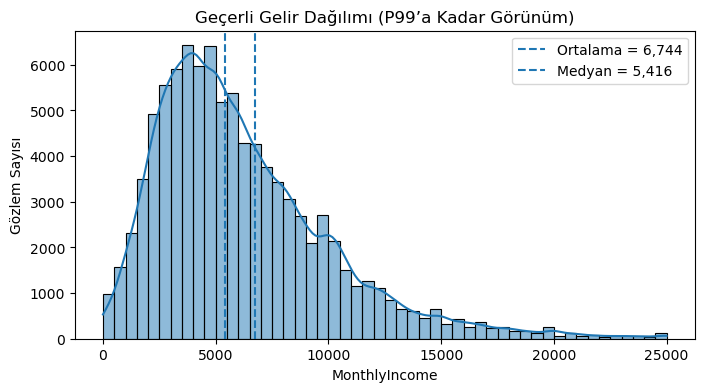

In [39]:
# =============================================================================
# ADIM 3.2.1.1: UYGULAMA - MONTHLYINCOME MEDYAN İKAMESİ
# =============================================================================

col = 'MonthlyIncome'

median_income = df_work.loc[
    (df_work[col].notna()) & (df_work[col] > 0), col
].median()

# NaN ve 0 değerlerini medyan ile ikame et
mask = df_work[col].isna() | (df_work[col] == 0)

df_work.loc[mask, col] = median_income

print(f"İkame Edilen Gözlem : {mask.sum()}")
print(f"İkame Medyanı       : {median_income:,.0f}")
print(f"Kalan Eksik Değer   : {df_work[col].isna().sum()}")
print(f"Kalan Sıfır Değer   : {(df_work[col] == 0).sum()}")

# =============================================================================
# ADIM 3.2.1.2: GÖRSEL DOĞRULAMA 
# =============================================================================

p99 = valid_income.quantile(0.99)

plt.figure(figsize=(8, 4))

sns.histplot(
    valid_income[valid_income <= p99],
    bins=50,
    kde=True
)

plt.axvline(
    valid_income.mean(),
    linestyle='--',
    label=f"Ortalama = {valid_income.mean():,.0f}"
)

plt.axvline(
    valid_income.median(),
    linestyle='--',
    label=f"Medyan = {valid_income.median():,.0f}"
)

plt.title('Geçerli Gelir Dağılımı (P99’a Kadar Görünüm)')
plt.xlabel("MonthlyIncome")
plt.ylabel("Gözlem Sayısı")
plt.legend()

plt.show()

In [40]:
# =============================================================================
# ADIM 3.2.2: NUMBEROFDEPENDENTS - İKAME YÖNTEMİ SEÇİMİ
# =============================================================================

col = 'NumberOfDependents'

valid_dependents = df_work[col].dropna()

print("--- NumberOfDependents İkame Adayları ---")
print(f"Ortalama : {valid_dependents.mean():.2f}")
print(f"Medyan   : {valid_dependents.median():.0f}")
print(f"Mod      : {valid_dependents.mode()[0]:.0f}")
print(f"Çarpıklık: {valid_dependents.skew():.2f}")

--- NumberOfDependents İkame Adayları ---
Ortalama : 0.76
Medyan   : 0
Mod      : 0
Çarpıklık: 1.60


#### ANALİST YORUMU

NumberOfDependents değişkeninde geçerli gözlemlerin ortalaması 0.76, medyanı ve modu ise 0 olarak hesaplanmıştır. Değişkenin kesikli sayım yapısı ve sağa çarpık dağılımı nedeniyle eksik değerlerin ikamesinde medyan tercih edilmiştir.

Medyanın 0 olması nedeniyle 3.128 eksik gözlem sıfırla ikame edilecektir. Ancak 0 aynı zamanda geçerli bir değer olduğundan, başlangıçta eksik olan gözlemler Is_Dependents_Missing göstergesiyle ayrıca korunacaktır.

İkame Edilen Gözlem : 3128
İkame Medyanı       : 0
Kalan Eksik Değer   : 0


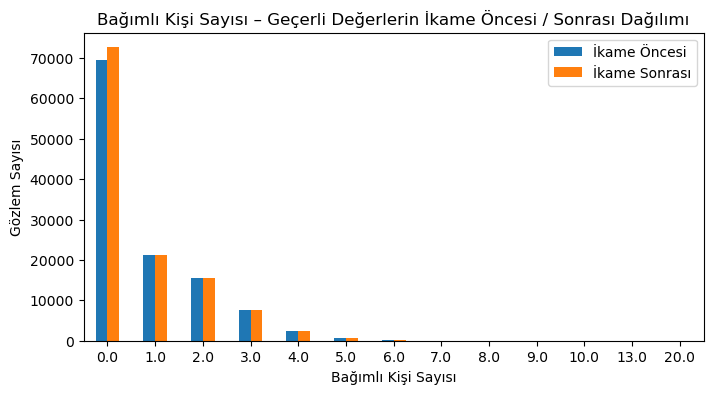

In [41]:
# =============================================================================
# ADIM 3.2.2.1: UYGULAMA - NUMBEROFDEPENDENTS İKAMESİ
# =============================================================================

col = 'NumberOfDependents'

# İkame öncesi dağılımı sakla
before_dependents = df_work[col].copy()

# Eksiklik bilgisini koru
df_work['Is_Dependents_Missing'] = df_work[col].isna().astype('uint8')

# Medyan ile ikame
median_dependents = df_work[col].median()
df_work[col] = df_work[col].fillna(median_dependents)

print(f"İkame Edilen Gözlem : {df_work['Is_Dependents_Missing'].sum()}")
print(f"İkame Medyanı       : {median_dependents:.0f}")
print(f"Kalan Eksik Değer   : {df_work[col].isna().sum()}")

# =============================================================================
# GÖRSEL DOĞRULAMA
# =============================================================================

before_counts = before_dependents.value_counts().sort_index()
after_counts = df_work[col].value_counts().sort_index()

validation = pd.DataFrame({
    'İkame Öncesi': before_counts,
    'İkame Sonrası': after_counts
}).fillna(0)

validation.plot(
    kind='bar',
    figsize=(8, 4)
)

plt.title('Bağımlı Kişi Sayısı – Geçerli Değerlerin İkame Öncesi / Sonrası Dağılımı')
plt.xlabel("Bağımlı Kişi Sayısı")
plt.ylabel("Gözlem Sayısı")
plt.xticks(rotation=0)
plt.show()

In [42]:
# =============================================================================
# ADIM 3.2.3: EKSİK VERİ SON KONTROLÜ
# =============================================================================

print("Toplam Eksik Değer :", df_work.isna().sum().sum())

Toplam Eksik Değer : 0


In [43]:
# =============================================================================
# ADIM 3.3.1: FEATURE ENGINEERING - FLAG DEĞİŞKENLERİNİN KONTROLÜ
# =============================================================================

flag_cols = [
    'Is_Delay_Anomaly',
    'Is_Utilization_Anomaly',
    'Is_Income_Missing',
    'Is_Zero_Open_Credits',
    'Is_Dependents_Missing'
]

flag_summary = pd.DataFrame({
    'Gozlem_Sayisi': df_work[flag_cols].sum(),
    'Oran_%': df_work[flag_cols].mean() * 100
})

display(flag_summary.round(2))

,Gozlem_Sayisi,Oran_%
Is_Delay_Anomaly,214,0.18
Is_Utilization_Anomaly,190,0.16
Is_Income_Missing,24997,20.83
Is_Zero_Open_Credits,1501,1.25
Is_Dependents_Missing,3128,2.61


#### ANALİST YORUMU

Oluşturulan beş flag değişkeninin frekansları, önceki analizlerde belirlenen gözlem sayılarıyla uyumludur. Is_Income_Missing %20.83 ile en yaygın gösterge olurken, gecikme ve kredi kullanım anomalileri daha sınırlı gözlem gruplarını temsil etmektedir.


#### ADIM 3.3.2: FEATURE ENGINEERING - YENİ DEĞİŞKENLER

Önceki analizlerde elde edilen bulgular doğrultusunda gecikme davranışı, gelir yeterliliği ve kredi kullanım yapısını birlikte değerlendirebilmek amacıyla aşağıdaki özellikler türetilecektir.

**1. TotalLatePayments (Toplam Gecikme Sayısı):**

30–59 gün, 60–89 gün ve 90+ gün gecikme değişkenlerinin toplamıdır. Kayıtlı gecikme sıklığını tek bir değişkende özetler.

**2. IncomePerPerson (Kişi Başına Gelir):**

MonthlyIncome / (NumberOfDependents + 1)

Geliri, müşteri ve bakmakla yükümlü olduğu kişi sayısını dikkate alarak değerlendirir.

**3. Is_High_Utilization (Yüksek Kredi Kullanım Göstergesi):**

RevolvingUtilizationOfUnsecuredLines >= 1 ise 1, aksi hâlde 0.

Teminatsız kredi kullanım oranı %100'e ulaşan veya bu seviyeyi aşan müşterileri işaretler.

**4. Unsecured_Credit_Count (Gayrimenkul Dışı Kredi Sayısı):**

NumberOfOpenCreditLinesAndLoans - NumberRealEstateLoansOrLines

Gayrimenkul kredileri dışındaki açık kredi ve kredi hatlarının yaklaşık sayısını temsil eder.

Türetilen özellikler doğrudan nihai modele dahil edilmeyecek; dağılımları, hedef değişkenle ilişkileri ve mevcut değişkenlerle oluşturdukları bilgi tekrarı incelendikten sonra özellik seçimi yapılacaktır.


In [44]:
# =============================================================================
# ADIM 3.3.2.1: TOPLAM GECİKME SAYISI - TOTALLATEPAYMENTS
# =============================================================================

delay_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

# Toplam gecikme sayısı
df_work['TotalLatePayments'] = df_work[delay_cols].sum(axis=1)

# Dağılım özeti
print("--- TotalLatePayments Dağılım Özeti ---")
print(f"Minimum : {df_work['TotalLatePayments'].min():.0f}")
print(f"Maksimum: {df_work['TotalLatePayments'].max():.0f}")

display(
    df_work['TotalLatePayments']
    .quantile([0.50, 0.90, 0.95, 0.99, 0.999])
)

# Risk analizi
late_bins = [-np.inf, 0, 1, 2, 3, 5, 10, np.inf]
late_labels = ['0', '1', '2', '3', '4-5', '6-10', '>10']

late_analysis = (
    df_work
    .assign(
        Grup=pd.cut(
            df_work['TotalLatePayments'],
            bins=late_bins,
            labels=late_labels
        )
    )
    .groupby('Grup', observed=True)['SeriousDlqin2yrs']
    .agg(
        Gozlem_Sayisi='size',
        Temerrut_Orani='mean'
    )
)

late_analysis['Temerrut_Orani'] *= 100

display(late_analysis.round(2))

--- TotalLatePayments Dağılım Özeti ---
Minimum : 0
Maksimum: 19


0.500     0.0
0.900     1.0
0.950     2.0
0.990     5.0
0.999    10.0
Name: TotalLatePayments, dtype: float64

,Gozlem_Sayisi,Temerrut_Orani
Grup,,
0,95906,2.86
1,13778,12.16
2,4798,23.93
3,2303,34.87
4-5,2026,45.95
6-10,1095,60.37
>10,94,67.02


#### ANALİST YORUMU

TotalLatePayments arttıkça temerrüt oranının belirgin ve düzenli şekilde yükseldiği görülmektedir. Hiç gecikmesi olmayan müşterilerde temerrüt oranı %2.86 iken, 1 gecikmede %12.16, 2 gecikmede %23.93 ve 6–10 gecikmede %60.37 seviyesine çıkmaktadır.

Bu sonuç, toplam gecikme sayısının müşterinin geçmiş ödeme davranışını özetleyen güçlü bir risk göstergesi olduğunu göstermektedir. TotalLatePayments türetilmiş değişken olarak korunacaktır.

In [45]:
# =============================================================================
# ADIM 3.3.2.2: KİŞİ BAŞINA GELİR - INCOMEPERPERSON
# =============================================================================

df_work['IncomePerPerson'] = (
    df_work['MonthlyIncome'] /
    (df_work['NumberOfDependents'] + 1)
)

# Temel dağılım
print("--- IncomePerPerson Dağılım Özeti ---")
print(f"Minimum : {df_work['IncomePerPerson'].min():,.2f}")
print(f"Maksimum: {df_work['IncomePerPerson'].max():,.2f}")

display(
    df_work['IncomePerPerson']
    .quantile([0.50, 0.90, 0.95, 0.99, 0.999])
)

# Gelir seviyesine göre risk ilişkisi
income_pp_bins = [
    -np.inf, 2500, 5000, 10000, 25000, 50000, np.inf
]

income_pp_labels = [
    '0-2.5K', '2.5K-5K', '5K-10K',
    '10K-25K', '25K-50K', '>50K'
]

income_pp_analysis = (
    df_work
    .assign(
        Grup=pd.cut(
            df_work['IncomePerPerson'],
            bins=income_pp_bins,
            labels=income_pp_labels
        )
    )
    .groupby('Grup', observed=True)['SeriousDlqin2yrs']
    .agg(
        Gozlem_Sayisi='size',
        Temerrut_Orani='mean'
    )
)

income_pp_analysis['Temerrut_Orani'] *= 100

display(income_pp_analysis.round(2))

--- IncomePerPerson Dağılım Özeti ---
Minimum : 0.17
Maksimum: 1,794,060.00


0.500     4007.00
0.900     8000.00
0.950    10443.00
0.990    17330.03
0.999    50001.00
Name: IncomePerPerson, dtype: float64

,Gozlem_Sayisi,Temerrut_Orani
Grup,,
0-2.5K,36264,9.36
2.5K-5K,34190,6.32
5K-10K,42950,5.15
10K-25K,6161,3.75
25K-50K,315,5.08
>50K,120,5.00


#### ANALİST YORUMU

IncomePerPerson arttıkça temerrüt oranının genel olarak azaldığı görülmektedir. Kişi başına geliri 2.500'ün altında olan müşterilerde temerrüt oranı %9.36 iken 2.5K–5K grubunda %6.32, 5K–10K grubunda %5.15 ve 10K–25K grubunda %3.75 seviyesine gerilemektedir.

25K üzerindeki gruplarda bu düşüş eğilimi devam etmemekle birlikte gözlem sayıları oldukça sınırlıdır. Genel bulgular, kişi başına gelirin müşterinin gelir yeterliliğini temsil eden ve hedef değişkenle anlamlı ilişki gösteren bir özellik olduğunu ortaya koymaktadır. IncomePerPerson korunacaktır.

In [46]:
# =============================================================================
# ADIM 3.3.2.3: YÜKSEK KREDİ KULLANIM GÖSTERGESİ - IS_HIGH_UTILIZATION
# =============================================================================

col = 'RevolvingUtilizationOfUnsecuredLines'

# Limit kullanım oranı %100 ve üzeri
df_work['Is_High_Utilization'] = (
    df_work[col] >= 1
).astype('uint8')

# Risk analizi
util_analysis = (
    df_work
    .groupby('Is_High_Utilization')['SeriousDlqin2yrs']
    .agg(
        Gozlem_Sayisi='size',
        Temerrut_Orani='mean'
    )
)

util_analysis['Temerrut_Orani'] *= 100

print("--- Is_High_Utilization / Risk İlişkisi ---")
display(util_analysis.round(2))

--- Is_High_Utilization / Risk İlişkisi ---


,Gozlem_Sayisi,Temerrut_Orani
Is_High_Utilization,,
0,117538,5.99
1,2462,39.64


#### ANALİST YORUMU

Kredi kullanım oranı %100'ün altında olan müşterilerde temerrüt oranı %5.99 iken, %100 ve üzeri kullanım gösteren müşterilerde bu oran %39.64 seviyesine yükselmektedir.

Bu belirgin ayrışma, yüksek kredi kullanımının güçlü bir risk göstergesi olduğunu ortaya koymaktadır. Is_High_Utilization değişkeni korunacaktır.

In [47]:
# =============================================================================
# ADIM 3.3.2.4: TEMİNATSIZ KREDİ SAYISI - UNSECURED_CREDIT_COUNT
# =============================================================================

df_work['Unsecured_Credit_Count'] = (
    df_work['NumberOfOpenCreditLinesAndLoans']
    - df_work['NumberRealEstateLoansOrLines']
)

# Temel dağılım
print("--- Unsecured_Credit_Count Dağılım Özeti ---")
print(f"Minimum : {df_work['Unsecured_Credit_Count'].min():.0f}")
print(f"Maksimum: {df_work['Unsecured_Credit_Count'].max():.0f}")

display(
    df_work['Unsecured_Credit_Count']
    .quantile([0.50, 0.90, 0.95, 0.99, 0.999])
)

# Risk analizi
credit_bins = [-np.inf, 0, 2, 5, 10, 20, np.inf]
credit_labels = ['0', '1-2', '3-5', '6-10', '11-20', '>20']

credit_analysis = (
    df_work
    .assign(
        Grup=pd.cut(
            df_work['Unsecured_Credit_Count'],
            bins=credit_bins,
            labels=credit_labels
        )
    )
    .groupby('Grup', observed=True)['SeriousDlqin2yrs']
    .agg(
        Gozlem_Sayisi='size',
        Temerrut_Orani='mean'
    )
)

credit_analysis['Temerrut_Orani'] *= 100

display(credit_analysis.round(2))

--- Unsecured_Credit_Count Dağılım Özeti ---
Minimum : 0
Maksimum: 57


0.500     7.0
0.900    14.0
0.950    16.0
0.990    23.0
0.999    33.0
Name: Unsecured_Credit_Count, dtype: float64

,Gozlem_Sayisi,Temerrut_Orani
Grup,,
0,1775,25.86
1-2,12048,9.45
3-5,33539,6.22
6-10,46840,5.79
11-20,23712,6.35
>20,2086,5.90


#### ANALİST YORUMU

Unsecured_Credit_Count = 0 olan müşterilerde temerrüt oranı %25.86 ile diğer gruplardan belirgin şekilde ayrışmaktadır. Bu oran, 1–2 grubunda %9.45'e, 3–5 grubunda ise %6.22'ye gerilemekte; daha yüksek kredi sayılarında yaklaşık %6 seviyesinde seyretmektedir.

Bu bulgu, gayrimenkul dışı açık kredi/kredi hattı bulunmamasının farklı bir müşteri ve risk profilini temsil ettiğini göstermektedir. Unsecured_Credit_Count analiz kapsamında korunacak; mevcut kredi sayısı değişkenleriyle oluşturduğu bilgi tekrarı nihai özellik seçimi aşamasında değerlendirilecektir.

In [48]:
# =============================================================================
# ADIM 3.3.3: FEATURE ENGINEERING - GENEL KONTROL
# =============================================================================

flag_cols = [
    'Is_Delay_Anomaly',
    'Is_Utilization_Anomaly',
    'Is_Income_Missing',
    'Is_Zero_Open_Credits',
    'Is_Dependents_Missing'
]

new_feature_cols = [
    'TotalLatePayments',
    'IncomePerPerson',
    'Is_High_Utilization',
    'Unsecured_Credit_Count'
]

feature_cols = flag_cols + new_feature_cols

feature_summary = pd.DataFrame({
    'Dtype': df_work[feature_cols].dtypes.astype(str),
    'Eksik_Sayisi': df_work[feature_cols].isna().sum(),
    'Unique_Sayisi': df_work[feature_cols].nunique(),
    'Minimum': df_work[feature_cols].min(),
    'Maksimum': df_work[feature_cols].max()
})

display(feature_summary)

,Dtype,Eksik_Sayisi,Unique_Sayisi,Minimum,Maksimum
Is_Delay_Anomaly,uint8,0,2,0.000000,1.0
Is_Utilization_Anomaly,uint8,0,2,0.000000,1.0
Is_Income_Missing,uint8,0,2,0.000000,1.0
Is_Zero_Open_Credits,uint8,0,2,0.000000,1.0
Is_Dependents_Missing,uint8,0,2,0.000000,1.0
TotalLatePayments,int64,0,20,0.000000,19.0
IncomePerPerson,float64,0,18781,0.166667,1794060.0
Is_High_Utilization,uint8,0,2,0.000000,1.0
Unsecured_Credit_Count,int64,0,54,0.000000,57.0


#### ANALİST YORUMU

Feature Engineering kapsamında oluşturulan 5 gösterge ve 4 türetilmiş değişkenin tamamında eksik değer bulunmadığı, veri tiplerinin ve değer aralıklarının beklenen yapıyla uyumlu olduğu doğrulanmıştır. IncomePerPerson değişkenindeki geniş üst kuyruk, dönüşüm aşamasında ayrıca değerlendirilecektir.

In [49]:
# =============================================================================
# ADIM 3.4: KATEGORİK DEĞİŞKEN KODLAMA - ENCODING
# =============================================================================

categorical_cols = df_work.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print("Kategorik Değişkenler:", categorical_cols)

Kategorik Değişkenler: []


#### ANALİST YORUMU

Veri setinde kategorik değişken bulunmadığından ek bir encoding işlemine ihtiyaç duyulmamıştır. Oluşturulan binary değişkenler mevcut 0/1 yapılarıyla korunacaktır.


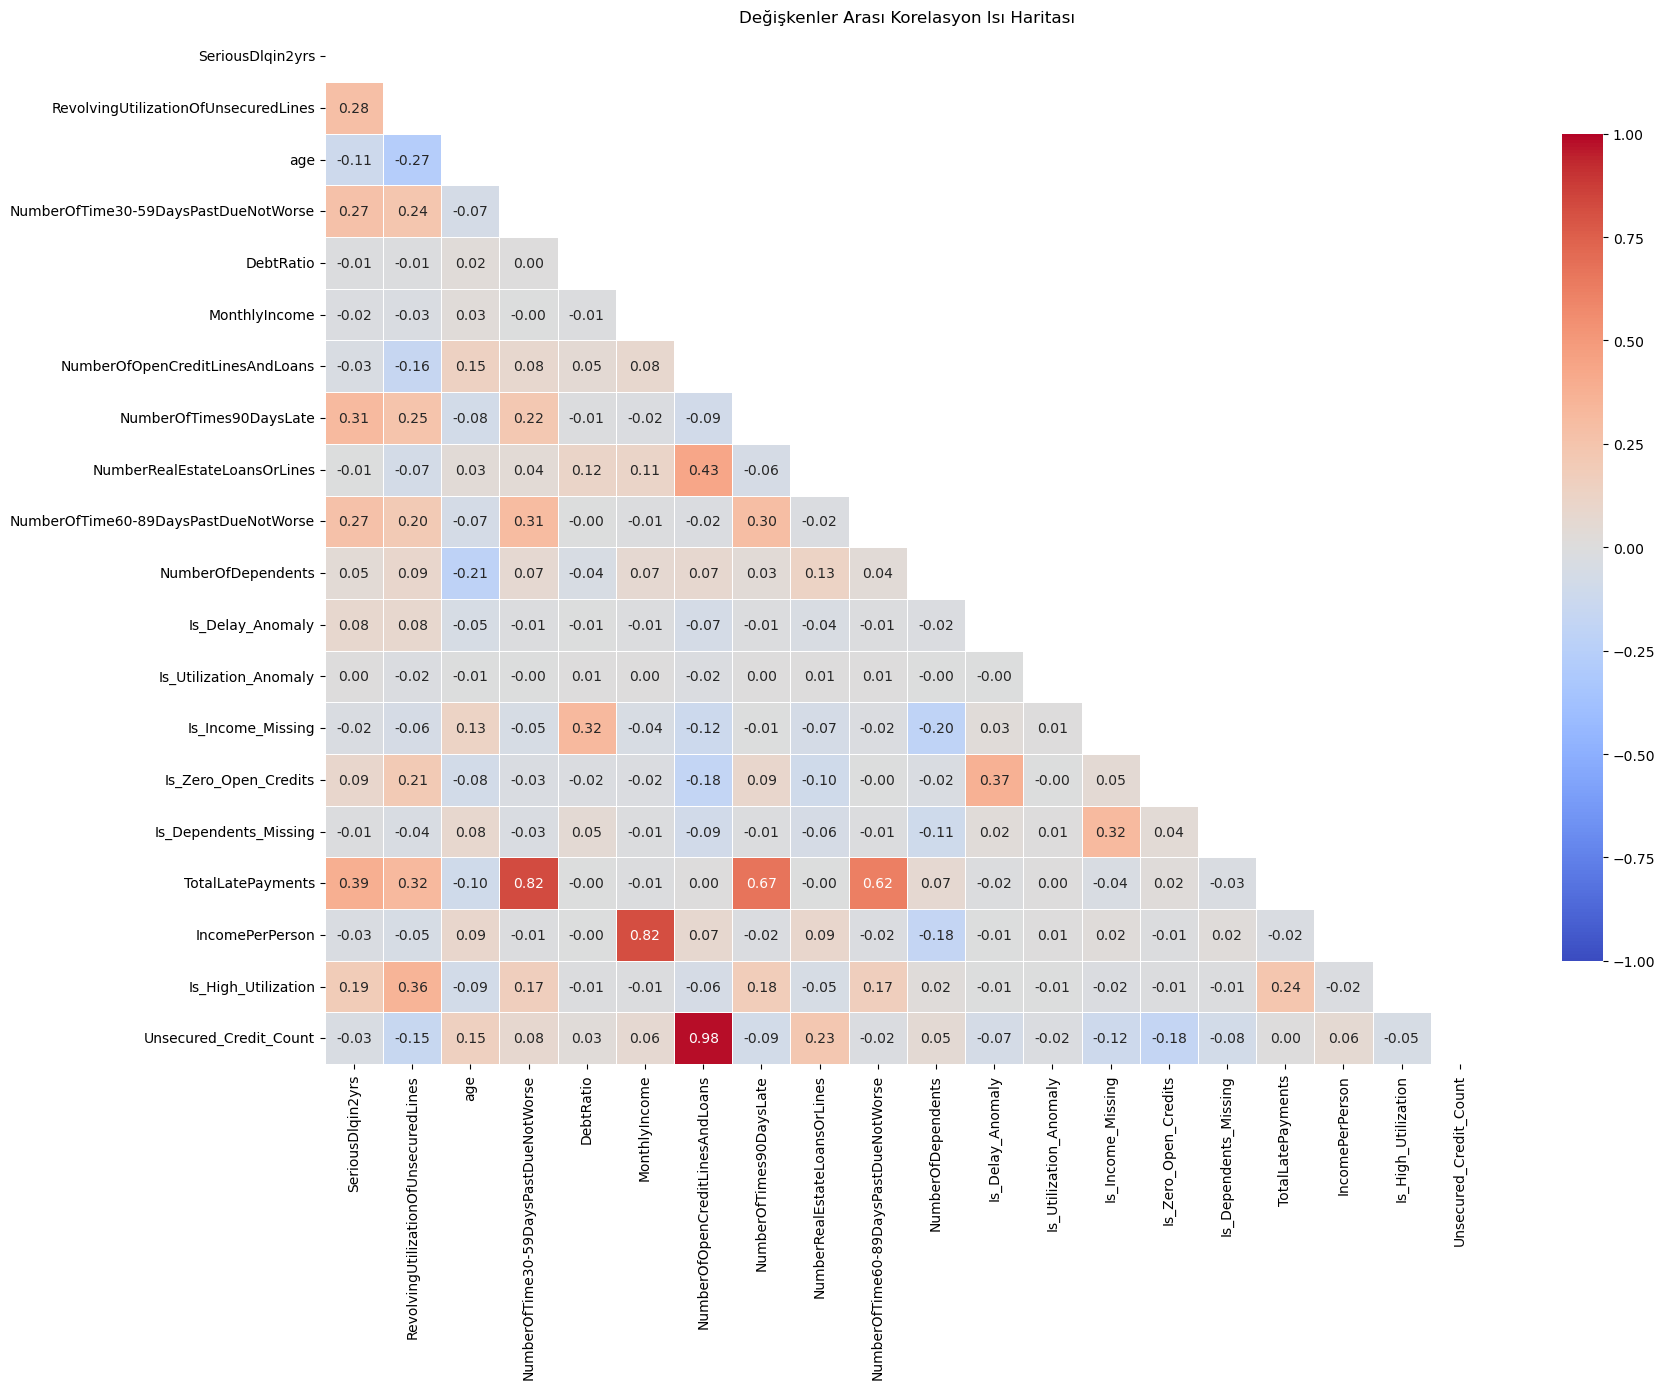

In [50]:
# =============================================================================
# ADIM 3.5.1: KORELASYON ISI HARİTASI
# =============================================================================

corr_matrix = df_work.corr(numeric_only=True)

# Üst üçgeni gizle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(18, 14))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.title('Değişkenler Arası Korelasyon Isı Haritası')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### ANALİST YORUMU

Korelasyon analizi, türetilmiş değişkenler ile kaynak değişkenleri arasında beklenen yüksek ilişkileri göstermektedir. Özellikle Unsecured_Credit_Count ile açık kredi sayısı (0.98), TotalLatePayments ile gecikme değişkenleri (0.62–0.82) ve IncomePerPerson ile MonthlyIncome (0.82) arasında güçlü korelasyonlar bulunmaktadır.

Hedef değişken açısından TotalLatePayments 0.39 ile incelenen değişkenler arasındaki en yüksek doğrusal korelasyonu göstermiştir. Bu sonuç, gecikme davranışlarının tek bir toplam değişkende birleştirilmesinin hedef değişken açısından dikkate değer bir sinyal taşıdığını göstermektedir.

Bu aşamada korelasyon değerleri tek başına değişken eleme kriteri olarak kullanılmayacaktır; yüksek ilişkili değişkenler sonraki IV ve VIF analizlerinde değerlendirilecektir.

In [51]:
# =============================================================================
# ADIM 3.6: BİLGİ KAZANCI VE ÖNEM ANALİZİ (FEATURE SELECTION)
# =============================================================================

# Gecikme sıklığı gibi her sayısal seviyesi doğrudan davranışsal anlam taşıyan ve düşük/orta cardinality yapıda olan count değişkenleri ayrı tutulur.
# Bu değişkenlerde 0, 1, 2, 3... değerlerinin kendisi anlamlı olduğundan quantile bazlı gruplama yerine mevcut seviyeler korunur.

# Örneğin:
# 0 = hiç gecikme yok
# 1 = bir kez gecikme
# 2 = iki kez gecikme

# Özellikle sıfır değerlerin yoğun olduğu gecikme değişkenlerinde qcut kullanılması, aynı quantile sınırlarının oluşmasına ve bazı grupların
# birleşerek bilgi kaybına uğramasına neden olabilir.
discrete_features = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfDependents',
    'TotalLatePayments']

def calculate_iv(df, feature, target, bins=10):
    temp = df[[feature, target]].copy()

# Binary değişkenler zaten doğal olarak iki gruptan oluştuğu için mevcut 0/1 yapıları korunur.
# Belirlenen count değişkenlerinde ise her seviye ayrı bir davranışsal anlam taşıdığı için mevcut değerler doğrudan bucket olarak kullanılır.
# Diğer sürekli veya yüksek cardinality sayısal değişkenlerde ise gözlemleri daha dengeli gruplara ayırmak amacıyla quantile bazlı binning uygulanır.
    
    if temp[feature].nunique() == 2 or feature in discrete_features:
        temp['bucket'] = temp[feature]
    else:
        temp['bucket'] = pd.qcut(temp[feature],q=bins,duplicates='drop')

# Her bucket içerisindeki toplam gözlem ve default (Bad) sayısı hesaplanır. Good gözlem sayısı toplamdan Bad çıkarılarak elde edilir.
    grouped = temp.groupby('bucket',observed=True)[target].agg(Total='count',Bad='sum')
    grouped['Good'] = grouped['Total'] - grouped['Bad']

# Her bucket'ın toplam Good ve Bad popülasyonu içerisindeki payı hesaplanır.
    grouped['Good_Dist'] = (grouped['Good'] / grouped['Good'].sum())
    grouped['Bad_Dist'] = (grouped['Bad'] / grouped['Bad'].sum())

# Bazı bucket'larda hiç Good veya hiç Bad gözlem bulunmaması halinde log(0) problemi oluşabilir. Bunu önlemek için çok küçük bir alt sınır uygulanır.
    eps = 0.0001
    grouped['Good_Dist'] = grouped['Good_Dist'].clip(lower=eps)
    grouped['Bad_Dist'] = grouped['Bad_Dist'].clip(lower=eps)

# Weight of Evidence (WoE): Bucket içerisindeki Good ve Bad dağılımlarının göreli farkını gösterir.
    grouped['WoE'] = np.log(grouped['Good_Dist'] /grouped['Bad_Dist'])
    
# Information Value: Her bucket'ın hedef sınıfı ayırma katkısı hesaplanır ve değişken seviyesinde toplam IV skoru elde edilir.
    grouped['IV'] = (grouped['Good_Dist'] - grouped['Bad_Dist']) * grouped['WoE']
    return grouped['IV'].sum()
    
# Target değişkeni hariç tüm aday değişkenlerin IV skorları hesaplanır.
iv_scores = {
    col: calculate_iv(df_work,col,'SeriousDlqin2yrs')
    for col in df_work.columns
    if col != 'SeriousDlqin2yrs'
}
# IV skorları yüksekten düşüğe sıralanır.
iv_summary = (pd.DataFrame.from_dict(iv_scores,orient='index',columns=['IV_Score']).sort_values('IV_Score',ascending=False))

# IV değerlerinin yorumlanmasını kolaylaştırmak amacıyla yaygın kullanılan referans aralıkları kullanılır. 
# Bu sınıflar mekanik bir eleme kuralı olarak değerlendirilmez.
def interpret_iv(iv):
    if iv < 0.02:
        return "Çok Düşük"
    elif iv < 0.10:
        return "Zayıf"
    elif iv < 0.30:
        return "Orta"
    elif iv < 0.50:
        return "Güçlü"
    else:
        return "Çok Güçlü"

iv_summary['Interpretation'] = (iv_summary['IV_Score'].apply(interpret_iv))

# NOT: IV skoru kullanılan binning yöntemine duyarlıdır. Bu nedenle IV tek başına değişken eleme kriteri olarak kullanılmayacak; korelasyon, VIF ve 
# modelleme performansı ile birlikte değerlendirilecektir. Çok yüksek IV değerleri ise nihai aşamada veri sızıntısı açısından ayrıca kontrol edilecektir.

display(iv_summary.round(4))

,IV_Score,Interpretation
TotalLatePayments,1.3652,Çok Güçlü
RevolvingUtilizationOfUnsecuredLines,1.1093,Çok Güçlü
NumberOfTimes90DaysLate,0.8284,Çok Güçlü
NumberOfTime30-59DaysPastDueNotWorse,0.6910,Çok Güçlü
NumberOfTime60-89DaysPastDueNotWorse,0.5547,Çok Güçlü
Is_High_Utilization,0.2528,Orta
age,0.2463,Orta
IncomePerPerson,0.1039,Orta
DebtRatio,0.0736,Zayıf
MonthlyIncome,0.0696,Zayıf


#### ANALİST YORUMU

IV analizi, kredi kullanım ve gecikme davranışlarının hedef değişkeni ayrıştırmada öne çıktığını göstermektedir. 

TotalLatePayments 1.3652 ile en yüksek IV skoruna ulaşırken; RevolvingUtilizationOfUnsecuredLines 1.1093, 90+ gün gecikme 0.8284, 30–59 gün gecikme 0.6910 ve 60–89 gün gecikme 0.5547 ile yüksek IV değerleri göstermiştir. 

Özellikle Feature Engineering aşamasında oluşturulan TotalLatePayments değişkeninin hem korelasyon analizinde hedefle en yüksek doğrusal ilişkiyi göstermesi hem de IV analizinde ilk sırada yer alması, gecikme bilgilerinin birlikte değerlendirilmesinin anlamlı bir risk sinyali taşıdığını desteklemektedir.

Is_High_Utilization, age ve IncomePerPerson orta düzeyde; gelir, borçluluk ve kredi sayısı değişkenleri ise daha sınırlı IV değerleri göstermiştir. 

Düşük IV değerine sahip değişkenler bu aşamada elenmeyecektir.

In [52]:
# =============================================================================
# ADIM 3.7: MULTICOLLINEARITY (ÇOKLU DOĞRUSALLIK) KONTROLÜ - VIF
# =============================================================================

# Hedef değişken VIF hesabına dahil edilmez.
# VIF yalnızca açıklayıcı değişkenlerin kendi aralarındaki doğrusal ilişkileri ölçmek amacıyla hesaplanır.
X_vif = df_work.drop(columns='SeriousDlqin2yrs').copy()

# VIF hesabının sayısal olarak güvenli çalışması için tüm değişkenler float veri tipine dönüştürülür.
X_vif = X_vif.astype('float64')

# Her değişkenin diğer açıklayıcı değişkenler tarafından ne ölçüde açıklanabildiğini gösteren VIF değerleri hesaplanır.
vif_summary = pd.DataFrame({
    'Variable': X_vif.columns,
    'VIF': [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif_summary = (
    vif_summary
    .sort_values('VIF', ascending=False)
    .reset_index(drop=True)
)
# NOT:
# VIF değeri yüksek olan değişkenler doğrudan modelden çıkarılmayacaktır.
# Sonuçlar korelasyon, IV ve değişkenlerin finansal anlamlarıyla birlikte değerlendirilerek olası bilgi tekrarları incelenecektir.
# VIF özellikle doğrusal modeller açısından önem taşırken, ağaç tabanlı modeller aynı ölçüde bu varsayıma bağlı değildir.
display(vif_summary.round(2))

C:\Users\tortu\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Variable,VIF
0,NumberOfTime30-59DaysPastDueNotWorse,inf
1,NumberOfOpenCreditLinesAndLoans,inf
2,NumberOfTimes90DaysLate,inf
3,TotalLatePayments,inf
4,Unsecured_Credit_Count,inf
5,NumberOfTime60-89DaysPastDueNotWorse,inf
6,NumberRealEstateLoansOrLines,inf
7,age,4.86
8,IncomePerPerson,4.71
9,MonthlyIncome,4.29


#### VIF Değerlendirme Ölçütleri

****VIF < 5:**** Belirgin bir çoklu doğrusal bağlantı problemi bulunmadığına işaret eder.

****VIF = 5–10:**** Orta düzeyde çoklu doğrusal bağlantıya işaret eder ve değişkenin diğer göstergelerle birlikte değerlendirilmesini gerektirir.

****VIF > 10:**** Yüksek düzeyde çoklu doğrusal bağlantıya işaret eder ve model kararlılığını olumsuz etkileyebilir.

****VIF = ∞:**** Değişkenler arasında tam doğrusal bağımlılık bulunduğunu gösterir.

#### ANALİST YORUMU

VIF analizinde iki yapısal tam doğrusal bağımlılık tespit edilmiştir. 

TotalLatePayments üç gecikme değişkeninin toplamından, Unsecured_Credit_Count ise açık kredi sayısı ile gayrimenkul kredi sayısının farkından türetildiği için ilgili değişkenlerde VIF değerleri sonsuz (inf) hesaplanmıştır. 

Bunun dışındaki değişkenlerin tamamında VIF < 5 olması nedeniyle belirgin bir çoklu doğrusal bağlantı problemi gözlenmemiştir.

In [53]:
# =============================================================================
# ADIM 3.7.1: KORELASYON, IV VE VIF SONUÇLARININ BİRLİKTE DEĞERLENDİRİLMESİ
# =============================================================================

target = 'SeriousDlqin2yrs'

corr = df_work.corr(numeric_only=True)

target_corr = corr[target].drop(target).rename('Target_Correlation')

feature_corr = corr.drop(index=target, columns=target).abs()
np.fill_diagonal(feature_corr.values, np.nan)

feature_evaluation = pd.concat([
    target_corr,
    feature_corr.max().rename('Max_Feature_Correlation'),
    feature_corr.idxmax().rename('Highest_Correlation_With'),
    iv_summary['IV_Score'],
    vif_summary.set_index('Variable')['VIF']
], axis=1).sort_values('IV_Score', ascending=False)

display(feature_evaluation.round({
    'Target_Correlation': 2,
    'Max_Feature_Correlation': 2,
    'IV_Score': 4,
    'VIF': 2
}))

,Target_Correlation,Max_Feature_Correlation,Highest_Correlation_With,IV_Score,VIF
TotalLatePayments,0.39,0.82,NumberOfTime30-59DaysPastDueNotWorse,1.3652,inf
RevolvingUtilizationOfUnsecuredLines,0.28,0.36,Is_High_Utilization,1.1093,2.10
NumberOfTimes90DaysLate,0.31,0.67,TotalLatePayments,0.8284,inf
NumberOfTime30-59DaysPastDueNotWorse,0.27,0.82,TotalLatePayments,0.6910,inf
NumberOfTime60-89DaysPastDueNotWorse,0.27,0.62,TotalLatePayments,0.5547,inf
Is_High_Utilization,0.19,0.36,RevolvingUtilizationOfUnsecuredLines,0.2528,1.21
age,-0.11,0.27,RevolvingUtilizationOfUnsecuredLines,0.2463,4.86
IncomePerPerson,-0.03,0.82,MonthlyIncome,0.1039,4.71
DebtRatio,-0.01,0.32,Is_Income_Missing,0.0736,1.18
MonthlyIncome,-0.02,0.82,IncomePerPerson,0.0696,4.29


#### ANALİST YORUMU

Korelasyon, IV ve VIF sonuçları değişken bazında birlikte değerlendirilmiştir. Tam doğrusal bağımlılık oluşturan değişken gruplarında bilgi tekrarı azaltılarak, gecikme davranışını temsil etmek üzere hedef değişkenle daha yüksek korelasyon (0.39) ve IV (1.3652) gösteren TotalLatePayments korunacak; üç kaynak gecikme değişkeni aday setten çıkarılacaktır.

Benzer şekilde Unsecured_Credit_Count, açık kredi sayısıyla çok yüksek korelasyon (0.98) göstermesi, kaynak kredi değişkenlerinden türetilmesi ve ek ayrıştırma gücünün sınırlı olması nedeniyle çıkarılacaktır.

Is_Utilization_Anomaly ise hedef değişkenle doğrusal ilişkisinin ihmal edilebilir düzeyde olması (0.00) ve IV değerinin oldukça düşük olması (0.0002) nedeniyle aday setten çıkarılacaktır.

Diğer düşük IV'li değişkenler yalnızca tek değişkenli ayrıştırma güçlerine göre elenmemiş; eksiklik bilgisini veya özgün finansal yapıyı temsil etmeleri ve belirgin bir çoklu doğrusal bağlantı problemi oluşturmamaları nedeniyle korunacaktır.

In [54]:
# =============================================================================
# ADIM 3.7.2: MODELLEME ADAY ÖZELLİK SETİNİN OLUŞTURULMASI
# =============================================================================

excluded_features = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'Unsecured_Credit_Count',
    'Is_Utilization_Anomaly'
]
# df_work korunur; seçilen değişkenlerle modelleme aday veri seti oluşturulur.
df_selected = df_work.drop(columns=excluded_features).copy()

print("\nÇıkarılan Değişkenler:")
for col in excluded_features:
    print("-", col)

print("\nModelleme Aday Değişkenleri:")
for col in df_selected.columns:
    if col != 'SeriousDlqin2yrs':
        print("-", col)


Çıkarılan Değişkenler:
- NumberOfTime30-59DaysPastDueNotWorse
- NumberOfTimes90DaysLate
- NumberOfTime60-89DaysPastDueNotWorse
- Unsecured_Credit_Count
- Is_Utilization_Anomaly

Modelleme Aday Değişkenleri:
- RevolvingUtilizationOfUnsecuredLines
- age
- DebtRatio
- MonthlyIncome
- NumberOfOpenCreditLinesAndLoans
- NumberRealEstateLoansOrLines
- NumberOfDependents
- Is_Delay_Anomaly
- Is_Income_Missing
- Is_Zero_Open_Credits
- Is_Dependents_Missing
- TotalLatePayments
- IncomePerPerson
- Is_High_Utilization


In [55]:
# =============================================================================
# ADIM 3.8.1: Dağılım Normalleştirme (Transformation & Scaling)
# =============================================================================

# Binary değişkenler matematiksel dönüşüm gerektirmediğinden çarpıklık analizine dahil edilmez.
binary_features = [
    col for col in df_selected.columns
    if col != 'SeriousDlqin2yrs'
    and df_selected[col].nunique() == 2
]

continuous_features = [
    col for col in df_selected.columns
    if col != 'SeriousDlqin2yrs'
    and col not in binary_features
]

skew_summary = pd.DataFrame({
    'Min': df_selected[continuous_features].min(),
    'Median': df_selected[continuous_features].median(),
    'Mean': df_selected[continuous_features].mean(),
    'Max': df_selected[continuous_features].max(),
    'Skewness': df_selected[continuous_features].skew()
}).sort_values('Skewness', ascending=False)

display(skew_summary.round(3))

,Min,Median,Mean,Max,Skewness
MonthlyIncome,1.000,5416.000,6467.418,3008750.000,137.117
IncomePerPerson,0.167,4007.000,4627.686,1794060.000,117.190
DebtRatio,0.000,0.366,352.271,329664.000,99.144
TotalLatePayments,0.000,0.000,0.401,19.000,4.601
NumberRealEstateLoansOrLines,0.000,1.000,1.018,54.000,3.753
NumberOfDependents,0.000,0.000,0.738,20.000,1.636
RevolvingUtilizationOfUnsecuredLines,0.000,0.152,0.322,7.309,1.454
NumberOfOpenCreditLinesAndLoans,0.000,8.000,8.466,58.000,1.229
age,21.000,52.000,52.288,109.000,0.187


#### ANALİST YORUMU

MonthlyIncome, IncomePerPerson ve DebtRatio değişkenlerinde belirgin sağa çarpıklık görülmüş ve logaritmik dönüşüm için aday olarak belirlenmiştir. Diğer değişkenlerin mevcut yapılarının korunmasına karar verilmiştir.

In [56]:
# =============================================================================
# ADIM 3.8.2: LOGARİTMİK DÖNÜŞÜM
# =============================================================================

# Aşırı sağa çarpık sürekli değişkenlerde uç değerlerin etkisini azaltmak
# ve dağılımı daha dengeli hale getirmek amacıyla log1p dönüşümü uygulanır.
log_features = [
    'MonthlyIncome',
    'IncomePerPerson',
    'DebtRatio'
]

log_summary = []

for col in log_features:
    log_col = f'Log_{col}'
    df_selected[log_col] = np.log1p(df_selected[col])

    log_summary.append({
        'Variable': col,
        'Before_Skewness': df_selected[col].skew(),
        'After_Skewness': df_selected[log_col].skew()
    })

log_summary = pd.DataFrame(log_summary)

display(log_summary.round(3))

,Variable,Before_Skewness,After_Skewness
0,MonthlyIncome,137.117,-4.021
1,IncomePerPerson,117.190,-2.846
2,DebtRatio,99.144,1.754


#### ANALİST YORUMU

log1p dönüşümü DebtRatio çarpıklığını belirgin şekilde azaltmıştır. MonthlyIncome ve IncomePerPerson değişkenlerinde ise dağılım ters yönde çarpık hale geldiğinden, bu değişkenler için dönüşüm kararı dağılımlar görsel olarak incelendikten sonra verilecektir.

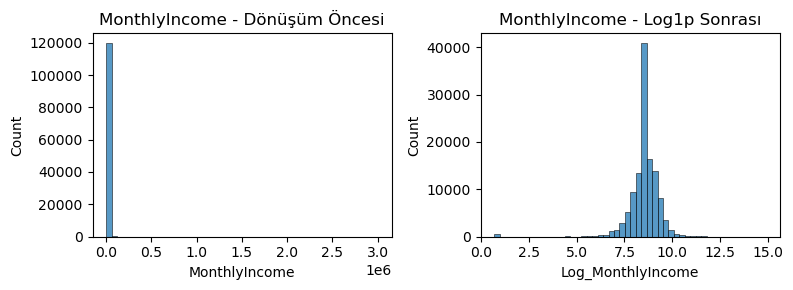

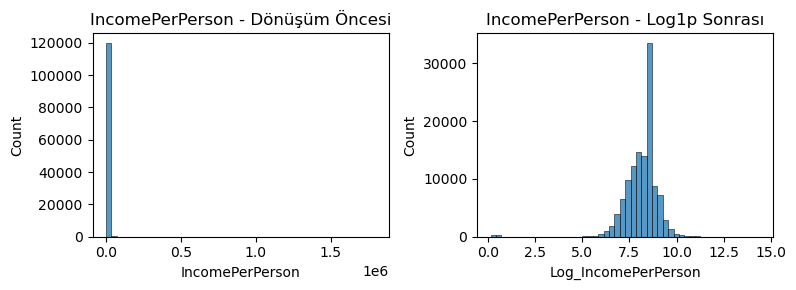

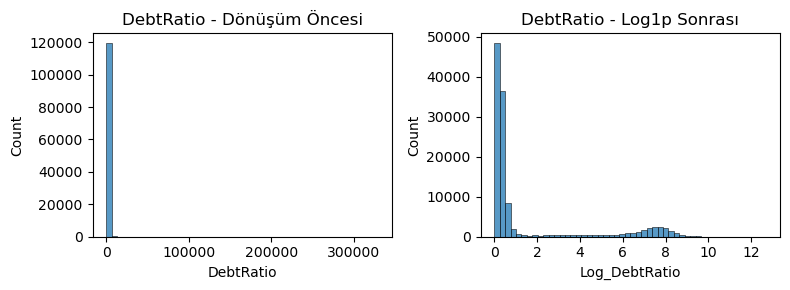

In [57]:
# =============================================================================
# ADIM 3.8.3: LOG DÖNÜŞÜMÜ ÖNCESİ VE SONRASI DAĞILIM KONTROLÜ
# =============================================================================

for col in log_features:
    log_col = f'Log_{col}'

    fig, axes = plt.subplots(1, 2, figsize=(8, 3))

    sns.histplot(df_selected[col], bins=50, ax=axes[0])
    axes[0].set_title(f'{col} - Dönüşüm Öncesi')

    sns.histplot(df_selected[log_col], bins=50, ax=axes[1])
    axes[1].set_title(f'{col} - Log1p Sonrası')

    plt.tight_layout()
    plt.show()

#### ANALİST YORUMU

log1p dönüşümü, üç değişkendeki geniş değer aralığını sıkıştırarak aşırı sağ kuyruğun baskınlığını azaltmıştır. 

Dönüşüm sonrasında MonthlyIncome ve IncomePerPerson sol çarpıklık gösterirken, DebtRatio daha düşük çarpıklıkla birlikte heterojen yapısını korumuştur. 

Bu doğrultuda, üç değişkenin log dönüşümlü versiyonlarıyla devam edilmesine karar verilmiştir.

In [58]:
# =============================================================================
# ADIM 3.8.4: DÖNÜŞÜMLERİN UYGULANMASI
# =============================================================================

# Log dönüşümü uygulanacak değişkenler
log_features = [
    'MonthlyIncome',
    'IncomePerPerson',
    'DebtRatio'
]

# Orijinal değişkenler log dönüşümlü değerleriyle değiştirilir.
for col in log_features:
    df_selected[col] = np.log1p(df_selected[col])

# Analiz amacıyla oluşturulan geçici Log_ kolonları kaldırılır.
temp_log_cols = [f'Log_{col}' for col in log_features]
df_selected.drop(columns=temp_log_cols, errors='ignore', inplace=True)

print("Dönüşüm sonrası veri boyutu:", df_selected.shape)
display(df_selected.head())

Dönüşüm sonrası veri boyutu: (120000, 15)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfDependents,Is_Delay_Anomaly,Is_Income_Missing,Is_Zero_Open_Credits,Is_Dependents_Missing,TotalLatePayments,IncomePerPerson,Is_High_Utilization
0,0,0.114987,62,7.518607,8.597297,5,1,2.0,0,1,0,0,0,7.499054,0
1,0,0.008705,73,0.404500,8.243019,6,1,0.0,0,0,0,0,0,8.243019,0
2,0,0.214501,32,0.192271,8.220672,8,0,2.0,0,0,0,0,0,7.122598,0
3,0,1.000000,60,4.779123,8.597297,5,0,0.0,0,1,0,0,0,8.597297,0
4,0,0.230493,60,0.701774,8.006701,10,1,0.0,0,0,0,0,0,8.006701,0


In [59]:
# =============================================================================
# ADIM 3.8.5: ÖLÇEKLEME (SCALING) STRATEJİSİ
# =============================================================================
binary_features = [c for c in df_selected.columns
                   if c != 'SeriousDlqin2yrs' and df_selected[c].nunique() == 2]

scaling_features = [c for c in df_selected.columns
                    if c != 'SeriousDlqin2yrs' and c not in binary_features]

scaler = StandardScaler()

print("Ölçeklenecek:", scaling_features)
print("\nBinary:", binary_features)

Ölçeklenecek: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines', 'NumberOfDependents', 'TotalLatePayments', 'IncomePerPerson']

Binary: ['Is_Delay_Anomaly', 'Is_Income_Missing', 'Is_Zero_Open_Credits', 'Is_Dependents_Missing', 'Is_High_Utilization']


#### ANALİST YORUMU

Ölçeğe duyarlı modellerde StandardScaler kullanılacaktır. Binary değişkenler ölçekleme dışında tutulacak ve veri sızıntısını önlemek amacıyla ölçekleme işlemi Cross-Validation Pipeline içerisinde gerçekleştirilecektir. Ağaç tabanlı modellerde ölçekleme uygulanmayacaktır.

### BÖLÜM 4: MODEL MİMARİSİ VE HİPER-PARAMETRE OPTİMİZASYONU

Bu bölümde model geliştirme süreci yalnızca df_train üzerinden yürütülecek, veri setinin başlangıç aşamasında ayrılan %20'lik test seti nihai değerlendirme aşamasına kadar kullanılmayacaktır. Bölüm 3'te df_work üzerinde gerçekleştirilen analizler sonucunda belirlenen anomali yönetimi, eksik değer doldurma, özellik mühendisliği, özellik seçimi ve dönüşüm kararları modelleme sürecine aktarılacaktır.

Veri sızıntısını önlemek amacıyla veriden parametre öğrenen işlemler Pipeline içerisinde gerçekleştirilecek ve her Cross-Validation katında yalnızca ilgili eğitim verisinden öğrenilecektir. Model geliştirme ve hiper-parametre optimizasyonu 5-Fold Stratified Cross-Validation altyapısında yürütülecektir.

Logistic Regression temel referans (baseline) model olarak ele alınacak; ardından Random Forest, XGBoost ve LightGBM modelleri değerlendirilecektir. Model seçiminde başta ROC-AUC ve Gini olmak üzere PR-AUC ve Recall, model kararlılığı ve açıklanabilirlik-performans dengesi birlikte değerlendirilecektir.

#### 4.1. Modelleme Verisinin Hazırlanması ve Pipeline Mimarisi

df_train üzerinden hedef ve bağımsız değişkenler ayrılacaktır. Bölüm 3'te belirlenen anomali işlemleri, eksik değer yönetimi, özellik mühendisliği, özellik seçimi ve log dönüşümleri Pipeline yapısına aktarılacaktır. Ölçekleme yalnızca ihtiyaç duyan modeller için Pipeline içerisinde uygulanacaktır.

#### 4.2. Baseline Model ve Hiper-Parametre Optimizasyonu

Logistic Regression baseline model olarak kurulacaktır. L1/L2 regularization, C ve class_weight gibi hiper-parametreler 5-Fold Stratified Cross-Validation ve GridSearchCV kullanılarak değerlendirilecek; belirlenen arama uzayında en yüksek CV ROC-AUC sonucunu veren parametre seti seçilecektir.

#### 4.3. Aday Modeller ve Hiper-Parametre Optimizasyonu

Doğrusal olmayan ilişkileri ve değişkenler arasındaki etkileşimleri yakalayabilmek amacıyla Random Forest, XGBoost ve LightGBM modelleri değerlendirilecektir. Her model aynı Cross-Validation altyapısında eğitilecek ve modele özgü hiper-parametre optimizasyonu gerçekleştirilecektir.

#### 4.4. Modellerin Karşılaştırılması ve Şampiyon Model Seçimi

Modeller başta ROC-AUC, Gini, PR-AUC ve Recall olmak üzere ortak performans metrikleri üzerinden karşılaştırılacaktır. Cross-Validation sonuçlarının değişkenliği, Train–Validation performans farkı ve açıklanabilirlik-performans dengesi birlikte değerlendirilerek Şampiyon Model seçilecektir.

#### 4.5. Şampiyon Model Detay Analizi

Seçilen modelin karar mekanizması ve değişkenlerin tahmin üzerindeki etkileri incelenecektir. Logistic Regression seçilmesi halinde katsayılar ve Odds Ratio, ağaç tabanlı bir model seçilmesi halinde ise modele uygun özellik önem ve açıklanabilirlik analizleri gerçekleştirilecektir.

#### 4.6. Karar Eşiği (Thresholding) ve Senaryo Analizi

Cross-Validation tahminleri üzerinden Savunma, Standart ve Büyüme olmak üzere üç farklı karar senaryosu oluşturulacaktır. Riskli müşterileri yakalama oranı ile iyi müşterilerin yanlış riskli işaretlenme oranı birlikte değerlendirilerek çalışma eşiği belirlenecektir.

#### 4.7. Nihai Test Seti Değerlendirmesi

Model, hiper-parametreler ve karar eşiği sabitlendikten sonra başlangıçta ayrılan %20'lik test seti ilk ve tek kez kullanılacaktır. Modelin genelleştirme performansı ROC-AUC, Gini, PR-AUC, Recall ve gerekli diğer sınıflandırma metrikleri üzerinden değerlendirilecektir.

#### 4.8. Canlı Sistem Müşteri Risk Tahmin Fonksiyonu

Nihai Pipeline, Şampiyon Model ve belirlenen karar eşiği tek bir tahmin akışında birleştirilecektir. Oluşturulan fonksiyon, yeni müşteri verisini aynı ön işleme adımlarından geçirerek model risk skorunu hesaplayacak ve belirlenen eşik doğrultusunda risk sınıflandırması üretecektir.

In [60]:
# =============================================================================
# ADIM 4.1.1: MODELLEME VERİSİNİN HAZIRLANMASI
# =============================================================================

target = 'SeriousDlqin2yrs'

X = df_train.drop(columns=target).copy()
y = df_train[target].copy()

print("X Boyutu:", X.shape)
print("y Boyutu:", y.shape)
print(f"Default Oranı: %{y.mean() * 100:.2f}")

X Boyutu: (120000, 10)
y Boyutu: (120000,)
Default Oranı: %6.68


#### 4.1.2. Ön İşleme Transformer'ının Oluşturulması

Bölüm 3'te belirlenen ön işleme kararları modelleme sürecinde `Pipeline` yapısına aktarılacaktır:

- **Gecikme Değişkenleri:** 96/98 → medyan ikame + `Is_Delay_Anomaly`; ardından `TotalLatePayments`.
- **Age:** 0 → medyan ikame.
- **Revolving Utilization:** >10 → medyan ikame; `Is_High_Utilization` oluşturulması.
- **Monthly Income:** 0/NaN → medyan ikame + `Is_Income_Missing`.
- **Number of Dependents:** NaN → medyan ikame + `Is_Dependents_Missing`.
- **Open Credit Lines:** 0 değeri korunarak `Is_Zero_Open_Credits` oluşturulması.
- **Real Estate Loans:** Uç değerlerin korunması.
- **Debt Ratio:** Uç değerlerin korunması.

Feature Engineering kapsamında `TotalLatePayments` ve `IncomePerPerson` oluşturulacak; `MonthlyIncome`, `IncomePerPerson` ve `DebtRatio` değişkenlerine `log1p` dönüşümü uygulanacaktır.

In [61]:
# =============================================================================
# ADIM 4.1.2: ÖN İŞLEME TRANSFORMER'I
# =============================================================================

class CreditPreprocessor(BaseEstimator, TransformerMixin):

    def __init__(self):
        self.late_cols = [
            'NumberOfTime30-59DaysPastDueNotWorse',
            'NumberOfTimes90DaysLate',
            'NumberOfTime60-89DaysPastDueNotWorse'
        ]

        self.final_features = [
            'RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio',
            'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
            'NumberRealEstateLoansOrLines', 'NumberOfDependents',
            'Is_Delay_Anomaly', 'Is_Income_Missing',
            'Is_Zero_Open_Credits', 'Is_Dependents_Missing',
            'TotalLatePayments', 'IncomePerPerson',
            'Is_High_Utilization'
        ]

    def fit(self, X, y=None):
        util = 'RevolvingUtilizationOfUnsecuredLines'

        self.late_medians_ = {
            c: X.loc[~X[c].isin([96, 98]), c].median()
            for c in self.late_cols
        }

        self.age_median_ = X.loc[X['age'] > 0, 'age'].median()
        self.util_median_ = X.loc[X[util] <= 10, util].median()

        self.income_median_ = X.loc[
            X['MonthlyIncome'].notna() & (X['MonthlyIncome'] > 0),
            'MonthlyIncome'
        ].median()

        self.dependents_median_ = X['NumberOfDependents'].median()

        return self

    def transform(self, X):
        X = X.copy()
        util = 'RevolvingUtilizationOfUnsecuredLines'

        # Anomali ve eksik veri işlemleri
        X['Is_Delay_Anomaly'] = X[self.late_cols].isin([96, 98]).any(axis=1).astype('uint8')

        for c in self.late_cols:
            X.loc[X[c].isin([96, 98]), c] = self.late_medians_[c]

        X.loc[X['age'] == 0, 'age'] = self.age_median_
        X.loc[X[util] > 10, util] = self.util_median_

        X['Is_Income_Missing'] = (
            X['MonthlyIncome'].isna() | (X['MonthlyIncome'] == 0)
        ).astype('uint8')

        X['MonthlyIncome'] = (
            X['MonthlyIncome']
            .replace(0, np.nan)
            .fillna(self.income_median_)
        )

        X['Is_Dependents_Missing'] = X['NumberOfDependents'].isna().astype('uint8')
        X['NumberOfDependents'] = X['NumberOfDependents'].fillna(self.dependents_median_)

        X['Is_Zero_Open_Credits'] = (
            X['NumberOfOpenCreditLinesAndLoans'] == 0
        ).astype('uint8')

        # Feature Engineering
        X['TotalLatePayments'] = X[self.late_cols].sum(axis=1)
        X['IncomePerPerson'] = X['MonthlyIncome'] / (X['NumberOfDependents'] + 1)
        X['Is_High_Utilization'] = (X[util] >= 1).astype('uint8')

        # Log dönüşümleri
        log_cols = ['MonthlyIncome', 'IncomePerPerson', 'DebtRatio']
        X[log_cols] = np.log1p(X[log_cols])

        return X[self.final_features]

In [62]:
# =============================================================================
# ADIM 4.1.3: SCALING YAPISI
# =============================================================================

binary_features = [
    'Is_Delay_Anomaly', 'Is_Income_Missing',
    'Is_Zero_Open_Credits', 'Is_Dependents_Missing',
    'Is_High_Utilization'
]

scaling_features = [
    'RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio',
    'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
    'NumberRealEstateLoansOrLines', 'NumberOfDependents',
    'TotalLatePayments', 'IncomePerPerson'
]

lr_scaler = ColumnTransformer([
    ('scale', StandardScaler(), scaling_features),
    ('binary', 'passthrough', binary_features)
])

#### 4.2. Baseline Model ve Hiper-Parametre Optimizasyonu

Logistic Regression, yorumlanabilir ve şeffaf yapısı nedeniyle baseline model olarak kullanılacaktır. Model ve ön işleme adımları tek bir `Pipeline` içerisinde birleştirilerek hiper-parametre optimizasyonu 5-Fold Stratified Cross-Validation ile gerçekleştirilecektir.

Model seçiminde **ROC-AUC ana optimizasyon metriği** olarak kullanılacak; **Gini, PR-AUC, Recall ve F1-Score** ise destekleyici performans göstergeleri olarak birlikte takip edilecektir.

In [63]:
# =============================================================================
# ADIM 4.2.1: BASELINE LOGISTIC REGRESSION & OPTİMİZASYON
# =============================================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_pipeline = Pipeline([
    ('preprocessor', CreditPreprocessor()),
    ('scaler', lr_scaler),
    ('model', LogisticRegression(max_iter=2000, random_state=42))
])

param_grid_lr = {
    'model__penalty': ['l1', 'l2'],
    'model__C': [0.01, 0.1, 1, 10],
    'model__class_weight': [None, 'balanced'],
    'model__solver': ['liblinear']
}

scoring = {
    'AUC': 'roc_auc',
    'PR_AUC': 'average_precision',
    'Recall': 'recall',
    'Precision': 'precision',
    'F1': 'f1'
}

grid_lr = GridSearchCV(
    lr_pipeline,
    param_grid_lr,
    scoring=scoring,
    refit='AUC',
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid_lr.fit(X, y)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor', CreditPreprocessor()),
                                       ('scaler',
                                        ColumnTransformer(transformers=[('scale',
                                                                         StandardScaler(),
                                                                         ['RevolvingUtilizationOfUnsecuredLines',
                                                                          'age',
                                                                          'DebtRatio',
                                                                          'MonthlyIncome',
                                                                          'NumberOfOpenCreditLinesAndLoans',
                                                                          'NumberRealEstateLoansOrLines',
                                                                          'Numbe...
                                       ('model',
                                        LogisticRegression(max_iter=2000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'model__C': [0.01, 0.1, 1, 10],
                         'model__class_weight': [None, 'balanced'],
                         'model__penalty': ['l1', 'l2'],
                         'model__solver': ['liblinear']},
             refit='AUC', return_train_score=True,
             scoring={'AUC': 'roc_auc', 'F1': 'f1',
                      'PR_AUC': 'average_precision', 'Precision': 'precision',
                      'Recall': 'recall'})

In [64]:
# =============================================================================
# ADIM 4.2.2: HİPER-PARAMETRE SONUÇLARININ DEĞERLENDİRİLMESİ
# =============================================================================

results = pd.DataFrame(grid_lr.cv_results_)

results['Gini'] = 2 * results['mean_test_AUC'] - 1
results['AUC_Gap'] = results['mean_train_AUC'] - results['mean_test_AUC']

summary_lr = results[[
    'param_model__class_weight',
    'param_model__C',
    'param_model__penalty',
    'mean_test_AUC',
    'Gini',
    'mean_test_PR_AUC',
    'mean_test_Recall',
    'mean_test_Precision',
    'mean_test_F1',
    'AUC_Gap',
    'std_test_AUC'
]].copy()

summary_lr.columns = [
    'Class_Weight', 'C', 'Penalty',
    'AUC', 'Gini', 'PR_AUC',
    'Recall', 'Precision', 'F1',
    'AUC_Gap', 'AUC_Std'
]

summary_lr = summary_lr.sort_values('AUC', ascending=False).reset_index(drop=True)

display(summary_lr.round(4))

print("En İyi Parametreler:", grid_lr.best_params_)

,Class_Weight,C,Penalty,AUC,Gini,PR_AUC,Recall,Precision,F1,AUC_Gap,AUC_Std
0,balanced,10.00,l1,0.8534,0.7069,0.3672,0.7354,0.2166,0.3347,0.0003,0.0041
1,balanced,10.00,l2,0.8534,0.7069,0.3672,0.7354,0.2166,0.3347,0.0003,0.0041
2,balanced,1.00,l1,0.8534,0.7069,0.3671,0.7354,0.2166,0.3346,0.0003,0.0041
3,balanced,1.00,l2,0.8534,0.7069,0.3671,0.7356,0.2167,0.3347,0.0003,0.0041
4,balanced,0.10,l1,0.8534,0.7068,0.3668,0.7359,0.2163,0.3343,0.0003,0.0042
5,balanced,0.10,l2,0.8534,0.7068,0.3668,0.7354,0.2164,0.3344,0.0003,0.0041
6,balanced,0.01,l2,0.8531,0.7063,0.3654,0.7366,0.2146,0.3323,0.0003,0.0041
7,balanced,0.01,l1,0.8528,0.7057,0.3642,0.7393,0.2127,0.3304,0.0002,0.0042
8,None,10.00,l1,0.8506,0.7011,0.3644,0.1647,0.5655,0.2550,0.0002,0.0042
9,None,10.00,l2,0.8506,0.7011,0.3644,0.1647,0.5655,0.2550,0.0002,0.0042


En İyi Parametreler: {'model__C': 10, 'model__class_weight': 'balanced', 'model__penalty': 'l1', 'model__solver': 'liblinear'}


In [65]:
# =============================================================================
# ADIM 4.2.3: EN İYİ LOGISTIC REGRESSION MODEL KARNESİ
# =============================================================================

res = grid_lr.cv_results_
i = grid_lr.best_index_

for metric in ['AUC', 'PR_AUC', 'Recall', 'Precision', 'F1']:
    train = res[f'mean_train_{metric}'][i]
    val = res[f'mean_test_{metric}'][i]
    print(f'{metric:<10}: Train={train:.4f} | Val={val:.4f} | Gap={train-val:.4f}')

auc = res['mean_test_AUC'][i]

print('-' * 55)
print(f'Gini     : {2 * auc - 1:.4f}')
print(f'AUC Std  : {res["std_test_AUC"][i]:.4f}')

AUC       : Train=0.8537 | Val=0.8534 | Gap=0.0003
PR_AUC    : Train=0.3668 | Val=0.3672 | Gap=-0.0004
Recall    : Train=0.7360 | Val=0.7354 | Gap=0.0006
Precision : Train=0.2170 | Val=0.2166 | Gap=0.0003
F1        : Train=0.3352 | Val=0.3347 | Gap=0.0005
-------------------------------------------------------
Gini     : 0.7069
AUC Std  : 0.0041


#### ANALİST YORUMU

En iyi Logistic Regression modeli **L1 regularization, C=10 ve balanced class weight** ile elde edilmiştir. Modelin Cross-Validation sonuçlarında **ROC-AUC 0.8534, Gini 0.7069 ve PR-AUC 0.3672** olarak gerçekleşirken, Recall **%73.54** seviyesinde ölçülmüştür.

Train ve Validation metriklerinin oldukça yakın olması (**AUC Gap: 0.0003**) ve foldlar arasındaki düşük değişkenlik (**AUC Std: 0.0041**), modelin belirgin bir overfitting bulgusu göstermediğine ve Cross-Validation performansının tutarlı olduğuna işaret etmektedir.

Precision'ın **%21.66** seviyesinde kalması, yüksek Recall karşılığında daha fazla güvenli müşterinin riskli olarak sınıflandırıldığını göstermektedir. Bu denge nihai model seçiminin ardından karar eşiği (threshold) analizi ile ayrıca değerlendirilecektir.

#### 4.3. Aday Modeller ve Hiper-Parametre Optimizasyonu

Logistic Regression ile oluşturulan baseline modelin ardından doğrusal olmayan ilişkileri ve değişken etkileşimlerini yakalayabilmek amacıyla **Random Forest, XGBoost ve LightGBM** modelleri değerlendirilecektir.

Tüm modeller aynı **5-Fold Stratified Cross-Validation** yapısı ve ortak performans metrikleriyle karşılaştırılacaktır. Ağaç tabanlı modeller ölçeklemeye ihtiyaç duymadığından `StandardScaler` uygulanmayacak, ancak ön işleme adımları her Cross-Validation eğitim katında `CreditPreprocessor` üzerinden yeniden öğrenilecektir.

In [66]:
# =============================================================================
# ADIM 4.3: ADAY MODELLERİN YARIŞTIRILMASI
# =============================================================================

# ---------------------------------------------------------------------------
# Logistic Regression (mevcut GridSearch sonucu)
# ---------------------------------------------------------------------------

r, i = grid_lr.cv_results_, grid_lr.best_index_

tournament = [{
    'Model': 'Logistic Regression',
    'AUC': r['mean_test_AUC'][i],
    'Gini': 2 * r['mean_test_AUC'][i] - 1,
    'PR_AUC': r['mean_test_PR_AUC'][i],
    'Recall': r['mean_test_Recall'][i],
    'Precision': r['mean_test_Precision'][i],
    'F1': r['mean_test_F1'][i],
    'AUC_Gap': r['mean_train_AUC'][i] - r['mean_test_AUC'][i],
    'AUC_Std': r['std_test_AUC'][i],
    'Best_Params': grid_lr.best_params_
}]

# ---------------------------------------------------------------------------
# Challenger Modeller: Her biri 16 kombinasyon x 5 Fold = 80 Fit
# ---------------------------------------------------------------------------

models = {

    'Random Forest': (
        RandomForestClassifier(random_state=42, n_jobs=-1),
        {
            'model__n_estimators': [200, 400],
            'model__max_depth': [6, 10],
            'model__min_samples_leaf': [5, 20],
            'model__class_weight': [None, 'balanced']
        }
    ),

    'XGBoost': (
        XGBClassifier(
            random_state=42,
            eval_metric='logloss',
            n_jobs=-1
        ),
        {
            'model__n_estimators': [200, 400],
            'model__learning_rate': [0.03, 0.05],
            'model__max_depth': [3, 5],
            'model__subsample': [0.8, 1.0]
        }
    ),

    'LightGBM': (
        LGBMClassifier(
            random_state=42,
            verbose=-1,
            n_jobs=-1
        ),
        {
            'model__n_estimators': [200, 400],
            'model__learning_rate': [0.03, 0.05],
            'model__num_leaves': [15, 31],
            'model__subsample': [0.8, 1.0]
        }
    )
}

# ---------------------------------------------------------------------------
# GridSearchCV
# ---------------------------------------------------------------------------

grids = {}

for name, (model, params) in models.items():

    print(f'{name} eğitiliyor...')

    pipeline = Pipeline([
        ('preprocessor', CreditPreprocessor()),
        ('model', model)
    ])

    grid = GridSearchCV(
        pipeline,
        params,
        scoring=scoring,
        refit='AUC',
        cv=cv,
        n_jobs=-1,
        return_train_score=True
    )

    grid.fit(X, y)
    grids[name] = grid

    r, i = grid.cv_results_, grid.best_index_
    auc = r['mean_test_AUC'][i]

    tournament.append({
        'Model': name,
        'AUC': auc,
        'Gini': 2 * auc - 1,
        'PR_AUC': r['mean_test_PR_AUC'][i],
        'Recall': r['mean_test_Recall'][i],
        'Precision': r['mean_test_Precision'][i],
        'F1': r['mean_test_F1'][i],
        'AUC_Gap': r['mean_train_AUC'][i] - auc,
        'AUC_Std': r['std_test_AUC'][i],
        'Best_Params': grid.best_params_
    })

# ---------------------------------------------------------------------------
# Model Karşılaştırma Tablosu
# ---------------------------------------------------------------------------

tournament_df = (
    pd.DataFrame(tournament)
    .sort_values('AUC', ascending=False)
    .reset_index(drop=True)
)

display(tournament_df.round(4))

Random Forest eğitiliyor...
XGBoost eğitiliyor...
LightGBM eğitiliyor...


,Model,AUC,Gini,PR_AUC,Recall,Precision,F1,AUC_Gap,AUC_Std,Best_Params
0,LightGBM,0.8631,0.7261,0.3924,0.1633,0.6027,0.2569,0.0210,0.0035,"{'model__learning_rate': 0.03, 'model__n_estim..."
1,XGBoost,0.8630,0.7260,0.3919,0.1681,0.5968,0.2622,0.0105,0.0035,"{'model__learning_rate': 0.05, 'model__max_dep..."
2,Random Forest,0.8610,0.7220,0.3866,0.0994,0.6325,0.1716,0.0212,0.0033,"{'model__class_weight': None, 'model__max_dept..."
3,Logistic Regression,0.8534,0.7069,0.3672,0.7354,0.2166,0.3347,0.0003,0.0041,"{'model__C': 10, 'model__class_weight': 'balan..."


#### ================================================
#### 4.4. MODEL KARŞILAŞTIRMASI VE ŞAMPİYON MODEL SEÇİMİ
#### ================================================

Ağaç tabanlı modeller baseline Logistic Regression'a göre daha yüksek ayrıştırma performansı göstermiştir. En yüksek ROC-AUC **0.8631 ile LightGBM** modelinde elde edilirken, XGBoost **0.8630**, Random Forest **0.8610** ve Logistic Regression **0.8534** seviyesinde gerçekleşmiştir. PR-AUC açısından da LightGBM **0.3924**, XGBoost **0.3919** ve Random Forest **0.3866** ile Logistic Regression'ın **0.3672** değerinin üzerinde performans göstermiştir.

Foldlar arasındaki AUC standart sapmalarının **0.0033–0.0041** aralığında olması, modellerin Cross-Validation performanslarının foldlar arasında benzer değişkenlik gösterdiğini ortaya koymaktadır. Train–Validation AUC farkları ise Logistic Regression'da **0.0003**, XGBoost'ta **0.0105**, LightGBM'de **0.0210** ve Random Forest'ta **0.0212** olarak gerçekleşmiştir. Bu değerler model karmaşıklığının izlenmesi açısından değerlendirilmiş, ancak tek başına model seçim kriteri olarak kullanılmamıştır.

Recall ve Precision değerleri mevcut karar eşiği ve kullanılan sınıf ağırlıklarından etkilendiğinden bu aşamada modeller arasında doğrudan seçim kriteri olarak değerlendirilmemiştir.

Model seçiminde predictive performans ile açıklanabilirlik arasındaki denge dikkate alınmıştır. Logistic Regression, en yüksek performansı gösteren LightGBM'e göre ROC-AUC'de **0.0097**, PR-AUC'de ise **0.0252** daha düşük sonuç üretmesine rağmen; katsayı ve Odds Ratio üzerinden değişken etkilerinin yönünün ve büyüklüğünün doğrudan incelenebilmesine olanak sağlamaktadır.

Bu doğrultuda, performans farkı kabul edilerek **açıklanabilirlik önceliği nedeniyle Logistic Regression şampiyon model** olarak belirlenmiştir. Daha yüksek predictive performans gösteren boosting modelleri ise challenger modeller olarak korunacaktır.

In [67]:
# =============================================================================
# ADIM 4.4.1: ŞAMPİYON MODELİN BELİRLENMESİ
# =============================================================================

champion_name = 'Logistic Regression'
champion_model = grid_lr.best_estimator_
champion_params = grid_lr.best_params_

champion_metrics = (
    tournament_df
    .loc[tournament_df['Model'] == champion_name]
    .drop(columns='Best_Params')
    .reset_index(drop=True)
)

display(champion_metrics.round(4))
print("En İyi Parametreler:", champion_params)

,Model,AUC,Gini,PR_AUC,Recall,Precision,F1,AUC_Gap,AUC_Std
0,Logistic Regression,0.8534,0.7069,0.3672,0.7354,0.2166,0.3347,0.0003,0.0041


En İyi Parametreler: {'model__C': 10, 'model__class_weight': 'balanced', 'model__penalty': 'l1', 'model__solver': 'liblinear'}


#### ================================================
#### 4.5. ŞAMPİYON MODEL DETAY ANALİZİ
#### ================================================

Şampiyon model olarak seçilen Logistic Regression'ın karar yapısı incelenecektir. Model katsayıları ve Odds Ratio değerleri üzerinden değişkenlerin risk tahmini üzerindeki yönü ve göreli etkisi değerlendirilecek, ardından Cross-Validation tabanlı Out-of-Fold tahmin olasılıkları oluşturulacaktır.

Bu bölümde elde edilen Out-of-Fold olasılıkları, sonraki aşamadaki karar eşiği ve senaryo analizlerinde kullanılacaktır.

,Feature,Coefficient,Odds_Ratio
0,Is_Delay_Anomaly,1.9647,7.1327
1,TotalLatePayments,0.8218,2.2747
2,RevolvingUtilizationOfUnsecuredLines,0.7138,2.0418
3,Is_Zero_Open_Credits,0.5669,1.7628
4,age,-0.2781,0.7572
5,Is_High_Utilization,0.2055,1.2282
6,Is_Income_Missing,0.1833,1.2011
7,NumberOfOpenCreditLinesAndLoans,0.1608,1.1744
8,NumberRealEstateLoansOrLines,0.1418,1.1523
9,DebtRatio,-0.1272,0.8806


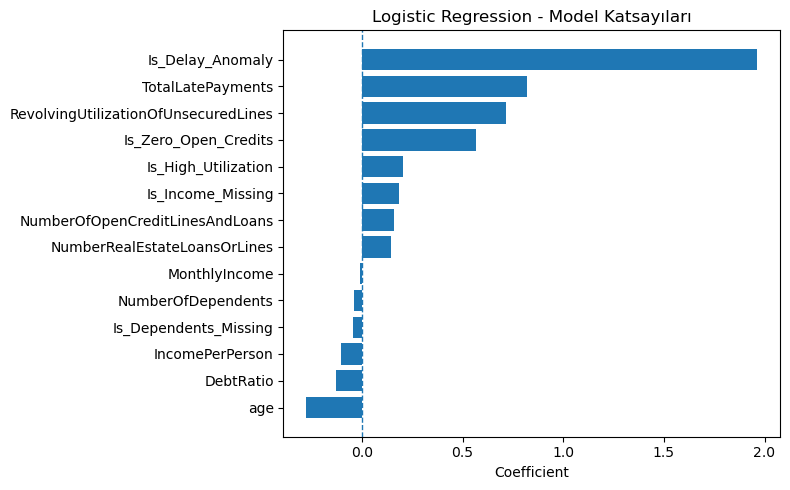

In [68]:
# =============================================================================
# ADIM 4.5.1: KATSAYI VE ODDS RATIO ANALİZİ
# =============================================================================

# Logistic Regression modeli ve değişken isimleri
lr_model = champion_model.named_steps['model']
lr_scaler = champion_model.named_steps['scaler']

feature_names = [
    name.replace('scale__', '').replace('binary__', '')
    for name in lr_scaler.get_feature_names_out()
]

# Katsayı ve Odds Ratio değerleri
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_[0],
    'Odds_Ratio': np.exp(lr_model.coef_[0])
})

# Mutlak katsayı büyüklüğüne göre sıralama
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()

coef_df = (
    coef_df
    .sort_values('Abs_Coefficient', ascending=False)
    .reset_index(drop=True)
)

# Sonuç tablosu
display(
    coef_df[['Feature', 'Coefficient', 'Odds_Ratio']].round(4)
)

# Katsayı grafiği
plot_df = coef_df.sort_values('Coefficient')

plt.figure(figsize=(8, 5))
plt.barh(plot_df['Feature'], plot_df['Coefficient'])
plt.axvline(0, linestyle='--', linewidth=1)

plt.title('Logistic Regression - Model Katsayıları')
plt.xlabel('Coefficient')
plt.ylabel('')

plt.tight_layout()
plt.show()

#### ANALİST YORUMU

Logistic Regression katsayıları, model kararında en güçlü pozitif etkinin **Is_Delay_Anomaly**, **TotalLatePayments** ve **RevolvingUtilizationOfUnsecuredLines** değişkenlerinden geldiğini göstermektedir.

Binary değişkenler arasında `Is_Delay_Anomaly` için Odds Ratio **7.13** seviyesindedir. Diğer değişkenler sabitken bu durumun gözlendiği müşterilerin model tarafından tahmin edilen default odds'u, gözlenmeyen müşterilere göre yaklaşık **7.1 kat** daha yüksektir. `Is_Zero_Open_Credits` (**1.76**), `Is_High_Utilization` (**1.23**) ve `Is_Income_Missing` (**1.20**) değişkenleri de default odds'unu artıran göstergeler olarak modele yansımıştır.

Ölçeklenen sayısal değişkenlerde ise katsayılar 1 standart sapmalık değişim üzerinden değerlendirilmelidir. `TotalLatePayments` için Odds Ratio **2.27**, `RevolvingUtilizationOfUnsecuredLines` için **2.04** olup bu değişkenlerdeki artışın default riski ile güçlü pozitif ilişki gösterdiğine işaret etmektedir. `age` değişkeninin negatif katsayısı ve **0.76 Odds Ratio** değeri ise yaş arttıkça modelin tahmin ettiği default odds'unun azaldığını göstermektedir.

Gelir değişkenlerinin etkisi görece sınırlı kalırken, modelin temel risk sinyalinin **gecikme geçmişi ve kredi kullanım davranışından** geldiği görülmektedir.

#### 4.5.2. Threshold Analizi İçin OOF Tahminlerinin Oluşturulması

Karar eşiğinin eğitim verisi üzerindeki doğrudan tahminlerden belirlenmesini önlemek amacıyla, şampiyon model için 5-Fold Stratified Cross-Validation kullanılarak Out-of-Fold (OOF) tahmin olasılıkları oluşturulacaktır.

Her gözlem, kendisinin eğitimde yer almadığı fold üzerinden tahmin edilerek bir sonraki bölümde gerçekleştirilecek threshold ve senaryo analizleri için kullanılacaktır.

In [69]:
# =============================================================================
# ADIM 4.5.2: THRESHOLD ANALİZİ İÇİN OOF TAHMİNLERİ
# =============================================================================

oof_proba = cross_val_predict(
    champion_model,
    X,
    y,
    cv=cv,
    method='predict_proba',
    n_jobs=-1
)[:, 1]

#### 4.6. Karar Eşiği (Threshold) ve Senaryo Analizi

Logistic Regression modeli müşteriler için bir tahmin skoru üretmektedir. Bu skorun hangi seviyeden itibaren riskli müşteri olarak sınıflandırılacağı karar eşiği (threshold) ile belirlenir.

Varsayılan 0.50 threshold her iş problemi için uygun olmak zorunda değildir. Kredi riskinde riskli müşterileri yakalama oranı (Recall) ile güvenli müşterilerin yanlış şekilde riskli sınıflandırılması (Precision) arasında bir denge bulunduğundan, farklı threshold seviyeleri Out-of-Fold tahminleri üzerinden karşılaştırılacaktır.

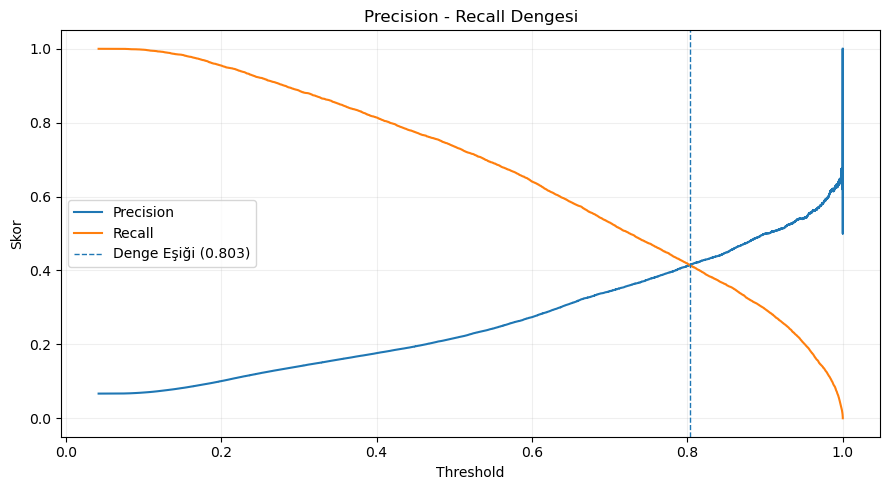

Denge Eşiği : 0.8031
Precision   : 0.4148
Recall      : 0.4148


In [70]:
# =============================================================================
# ADIM 4.6.1: PRECISION - RECALL DENGESİ
# =============================================================================

# Precision ve Recall değerleri
precisions, recalls, thresholds = precision_recall_curve(y, oof_proba)

# Precision ve Recall'un birbirine en yakın olduğu eşik
idx = np.argmin(np.abs(precisions[:-1] - recalls[:-1]))

balance_threshold = thresholds[idx]
balance_precision = precisions[idx]
balance_recall = recalls[idx]

# Precision - Recall grafiği
plt.figure(figsize=(9, 5))

plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')

plt.axvline(
    balance_threshold,
    linestyle='--',
    linewidth=1,
    label=f'Denge Eşiği ({balance_threshold:.3f})'
)

plt.title('Precision - Recall Dengesi')
plt.xlabel('Threshold')
plt.ylabel('Skor')
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print(f'Denge Eşiği : {balance_threshold:.4f}')
print(f'Precision   : {balance_precision:.4f}')
print(f'Recall      : {balance_recall:.4f}')

#### ANALİST YORUMU

Precision ve Recall değerlerinin dengelendiği eşik **0.8031** olarak belirlenmiş ve bu noktada her iki metrik de yaklaşık **%41.48** seviyesinde gerçekleşmiştir.

Threshold yükseldikçe model daha seçici davranmakta; Precision artarken Recall azalmaktadır. Buna karşılık threshold düşürüldüğünde daha fazla riskli müşteri yakalanmakta, ancak yanlış pozitiflerin artması nedeniyle Precision gerilemektedir.

Belirlenen **0.8031 değeri iş açısından optimum bir threshold olarak değil**, Precision ve Recall arasındaki dengeyi gösteren referans bir eşik olarak değerlendirilecektir. Nihai karar eşiği farklı risk senaryolarının karşılaştırılması sonucunda belirlenecektir.

#### 4.6.2. Stratejik Senaryo Analizi: Savunma – Standart – Büyüme

Farklı risk iştahlarının model kararlarına etkisini incelemek amacıyla 0.25, 0.50 ve 0.75 threshold seviyeleri karşılaştırılacaktır. Düşük threshold daha temkinli bir yaklaşımı temsil ederken, threshold yükseldikçe model riskli sınıflandırma konusunda daha seçici davranmaktadır.

0.25, 0.50 ve 0.75 eşikleri optimum karar eşikleri olarak değil; modelin düşük, orta ve yüksek risk iştahındaki davranışını karşılaştırmak amacıyla belirlenen senaryo seviyeleri olarak kullanılacaktır. Bu kapsamda senaryolar Savunma (0.25), Standart (0.50) ve Büyüme (0.75) olarak ele alınacaktır.

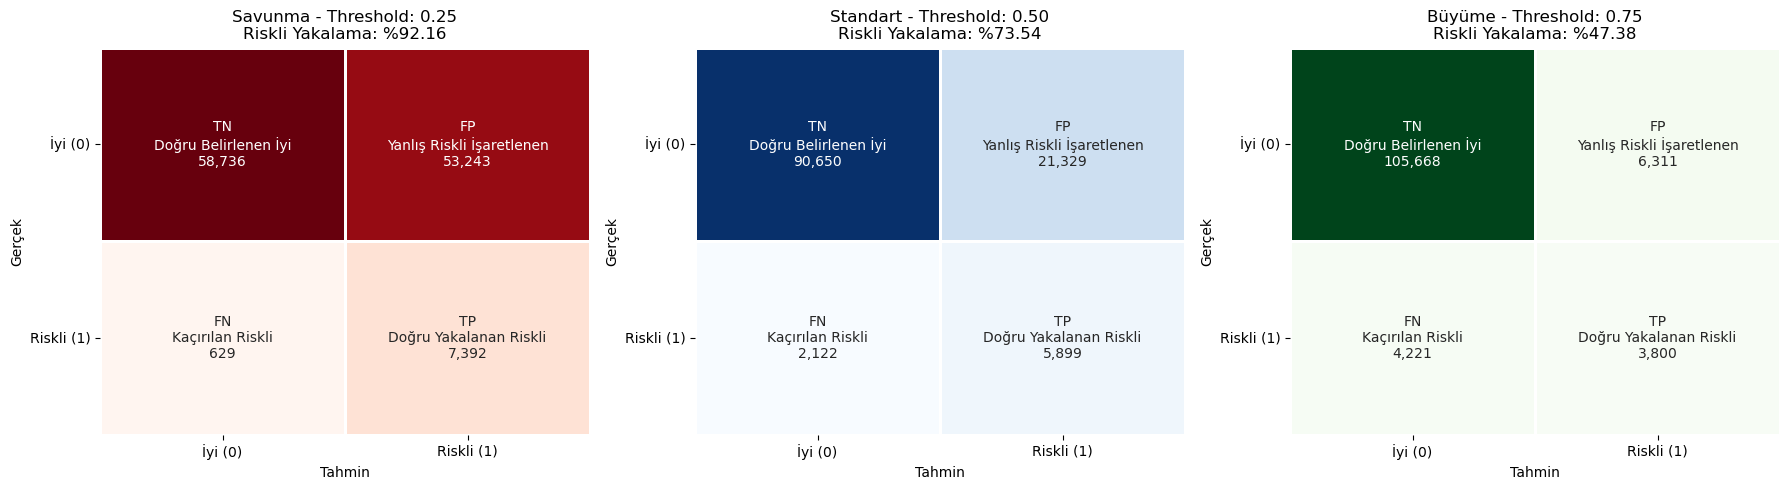

,Senaryo,Riskli Yakalama (%),Yanlış Riskli Oranı (%),Kaçırılan Riskli,Yanlış Riskli İşaretlenen
0,Savunma,92.16,47.55,629,53243
1,Standart,73.54,19.05,2122,21329
2,Büyüme,47.38,5.64,4221,6311



RİSK İŞTAHI GEÇİŞ ANALİZİ

[SAVUNMA → STANDART] (0.25 → 0.50)
1,493 ilave riskli müşteri kaçırılması karşılığında, 31,914 iyi müşteri yanlış riskli işaretlenmekten kurtulmaktadır.
→ Her 1 ilave kaçırılan riskliye karşılık yaklaşık 21.4 iyi müşteri yanlış riskli sınıflandırılmaktan kurtulmaktadır.

[STANDART → BÜYÜME] (0.50 → 0.75)
2,099 ilave riskli müşteri kaçırılması karşılığında, 15,018 iyi müşteri yanlış riskli işaretlenmekten kurtulmaktadır.
→ Her 1 ilave kaçırılan riskliye karşılık yaklaşık 7.2 iyi müşteri yanlış riskli sınıflandırılmaktan kurtulmaktadır.


In [71]:
# =============================================================================
# ADIM 4.6.2: STRATEJİK SENARYO ANALİZİ
# =============================================================================

thresholds = [0.25, 0.50, 0.75]
titles = ['Savunma', 'Standart', 'Büyüme']
colors = ['Reds', 'Blues', 'Greens']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
results, cms = [], {}

for threshold, title, color, ax in zip(thresholds, titles, colors, axes):

    y_pred = (oof_proba >= threshold).astype(int)
    cm = confusion_matrix(y, y_pred)
    tn, fp, fn, tp = cm.ravel()
    cms[threshold] = cm

    recall = 100 * tp / (tp + fn)
    fp_rate = 100 * fp / (fp + tn)

    # Teknik ve business karşılıklarının birlikte gösterilmesi
    labels = np.array([
        [f'TN\nDoğru Belirlenen İyi\n{tn:,}',
         f'FP\nYanlış Riskli İşaretlenen\n{fp:,}'],

        [f'FN\nKaçırılan Riskli\n{fn:,}',
         f'TP\nDoğru Yakalanan Riskli\n{tp:,}']
    ])

    sns.heatmap(
        cm,
        annot=labels,
        fmt='',
        cmap=color,
        cbar=False,
        linewidths=1,
        ax=ax
    )

    ax.set_title(
        f'{title} - Threshold: {threshold:.2f}\n'
        f'Riskli Yakalama: %{recall:.2f}'
    )
    ax.set_xlabel('Tahmin')
    ax.set_ylabel('Gerçek')
    ax.set_xticklabels(['İyi (0)', 'Riskli (1)'])
    ax.set_yticklabels(['İyi (0)', 'Riskli (1)'], rotation=0)

    results.append({
        'Senaryo': title,
        'Riskli Yakalama (%)': recall,
        'Yanlış Riskli Oranı (%)': fp_rate,
        'Kaçırılan Riskli': fn,
        'Yanlış Riskli İşaretlenen': fp
    })

plt.tight_layout()
plt.show()

# Senaryo sonuçları
scenario_df = pd.DataFrame(results)
display(scenario_df.round(2))

# Risk iştahı geçiş analizi
print('\nRİSK İŞTAHI GEÇİŞ ANALİZİ')

for t1, t2, label in [
    (0.25, 0.50, 'SAVUNMA → STANDART'),
    (0.50, 0.75, 'STANDART → BÜYÜME')
]:
    rescued_good = cms[t1][0, 1] - cms[t2][0, 1]
    missed_risky = cms[t2][1, 0] - cms[t1][1, 0]

    print(f'\n[{label}] ({t1:.2f} → {t2:.2f})')

    print(
        f'{missed_risky:,} ilave riskli müşteri kaçırılması karşılığında, '
        f'{rescued_good:,} iyi müşteri yanlış riskli işaretlenmekten kurtulmaktadır.'
    )

    print(
        f'→ Her 1 ilave kaçırılan riskliye karşılık yaklaşık '
        f'{rescued_good / missed_risky:.1f} iyi müşteri '
        f'yanlış riskli sınıflandırılmaktan kurtulmaktadır.'
    )

#### ANALİST YORUMU

Threshold seviyesi yükseldikçe model riskli sınıflandırma konusunda daha seçici davranmaktadır. Bu durum iyi müşterilerin yanlış riskli işaretlenmesini azaltırken, daha fazla gerçek riskli müşterinin kaçırılmasına neden olmaktadır.

**Savunma (0.25)** senaryosunda riskli müşterilerin **%92.16'sı** yakalanırken, iyi müşterilerin **%47.55'i** yanlış riskli olarak işaretlenmektedir. **Standart (0.50)** senaryosunda bu oranlar sırasıyla **%73.54** ve **%19.05** seviyesine gerilemektedir. **Büyüme (0.75)** senaryosunda ise yanlış riskli oranı **%5.64'e** kadar düşerken, riskli müşterilerin yalnızca **%47.38'i** yakalanabilmektedir.

Risk iştahı geçiş analizi, bu değişimin operasyonel karşılığını daha net göstermektedir. Savunma'dan Standart senaryoya geçişte her **1 ilave kaçırılan riskli müşteriye karşılık yaklaşık 21.4 iyi müşteri**, Standart'tan Büyüme senaryosuna geçişte ise yaklaşık **7.2 iyi müşteri** yanlış riskli sınıflandırılmaktan kurtulmaktadır.

Nihai karar eşiğinin gerçek uygulamada kurumun risk iştahı ile kaçırılan riskli ve yanlış riskli işaretlenen müşterilerin iş maliyetleri dikkate alınarak belirlenmesi gerekmektedir. Bu çalışma kapsamında ise risk yakalama ve yanlış riskli işaretleme arasındaki denge gözetilerek **0.50 çalışma threshold'u** baz alınacaktır.

In [72]:
final_threshold = 0.50

## 4.7. Nihai Test Seti Değerlendirmesi

Model geliştirme ve hiper-parametre optimizasyonu yalnızca eğitim verisi üzerinde tamamlanmıştır. Şampiyon model olarak Logistic Regression, çalışma karar eşiği olarak ise 0.50 belirlenmiştir.

Bu aşamada başlangıçta ayrılan ve model geliştirme sürecinde kullanılmayan %20'lik test seti üzerinde bağımsız performans değerlendirmesi gerçekleştirilecektir. Model, hiper-parametreler, ön işleme adımları ve karar eşiği değiştirilmeden korunacaktır.

Değerlendirmede ROC-AUC, Gini ve PR-AUC (Average Precision) ile birlikte belirlenen karar eşiğindeki Recall, Precision, F1-Score ve Confusion Matrix incelenecektir. Test sonuçları Cross-Validation performansıyla karşılaştırılarak modelin genelleme davranışı değerlendirilecektir.

In [73]:
# =============================================================================
# ADIM 4.7.1: NİHAİ TEST VERİSİNİN HAZIRLANMASI
# =============================================================================

X_test = df_test.drop(columns='SeriousDlqin2yrs').copy()
y_test = df_test['SeriousDlqin2yrs'].copy()

print(f"Test Seti: {len(y_test):,} gözlem")
print(f"Bağımsız Değişken: {X_test.shape[1]}")
print(f"Temerrüt Oranı: %{y_test.mean() * 100:.2f}")

Test Seti: 30,000 gözlem
Bağımsız Değişken: 10
Temerrüt Oranı: %6.68


In [74]:
# =============================================================================
# ADIM 4.7.2: NİHAİ TEST PERFORMANSI
# =============================================================================

# Eğitilmiş Pipeline ile tahmin (yeniden fit yapılmaz).
test_proba = champion_model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= final_threshold).astype(int)

# Performans metrikleri
test_auc = roc_auc_score(y_test, test_proba)

test_metrics = pd.DataFrame({
    'Metrik': ['ROC-AUC', 'Gini', 'PR-AUC (AP)', 'Recall', 'Precision', 'F1-Score'],
    'Test': [
        test_auc,
        2 * test_auc - 1,
        average_precision_score(y_test, test_proba),
        recall_score(y_test, test_pred),
        precision_score(y_test, test_pred),
        f1_score(y_test, test_pred)
    ]
})

print(f"Şampiyon Model: {champion_name}")
print(f"Karar Eşiği: {final_threshold:.2f}")
display(test_metrics.round(4))

Şampiyon Model: Logistic Regression
Karar Eşiği: 0.50


,Metrik,Test
0,ROC-AUC,0.8606
1,Gini,0.7212
2,PR-AUC (AP),0.3783
3,Recall,0.7471
4,Precision,0.2217
5,F1-Score,0.3419


#### ANALİST YORUMU 

Model, test setinde 0.8606 ROC-AUC ve 0.7212 Gini değerine ulaşmıştır. PR-AUC (Average Precision) 0.3783 olup %6.68 temerrüt oranına sahip dengesiz veri yapısında modelin riskli müşterileri ayırt etme performansını tamamlayıcı olarak göstermektedir.

Sabit 0.50 karar eşiğinde Recall %74.71, Precision %22.17 ve F1-Score 0.3419 olarak gerçekleşmiştir. Buna göre model, gerçek riskli müşterilerin yaklaşık dörtte üçünü tespit ederken riskli olarak işaretlediği müşterilerin yaklaşık %22'si gerçekten riskli sınıftadır. Bu sonuç, yanlış pozitif ve yanlış negatif kararlar arasındaki dengenin önemini koruduğunu göstermektedir.

In [75]:
# =============================================================================
# ADIM 4.7.3: CV - NİHAİ TEST KARŞILAŞTIRMASI
# =============================================================================

# Şampiyon modelin mevcut CV sonuçları
cv_row = tournament_df.loc[
    tournament_df['Model'] == champion_name
].iloc[0]

# Metrik isimlerini CV tablosuyla eşleştir
metric_map = {
    'ROC-AUC': 'AUC',
    'Gini': 'Gini',
    'PR-AUC (AP)': 'PR_AUC',
    'Recall': 'Recall',
    'Precision': 'Precision',
    'F1-Score': 'F1'
}

comparison_df = test_metrics.copy()

comparison_df['CV'] = comparison_df['Metrik'].map(
    lambda metric: cv_row[metric_map[metric]]
)

comparison_df['Fark (Test - CV)'] = comparison_df['Test'] - comparison_df['CV']

comparison_df = comparison_df[
    ['Metrik', 'CV', 'Test', 'Fark (Test - CV)']
]

display(comparison_df.round(4))

,Metrik,CV,Test,Fark (Test - CV)
0,ROC-AUC,0.8534,0.8606,0.0072
1,Gini,0.7069,0.7212,0.0144
2,PR-AUC (AP),0.3672,0.3783,0.0111
3,Recall,0.7354,0.7471,0.0117
4,Precision,0.2166,0.2217,0.0050
5,F1-Score,0.3347,0.3419,0.0072


#### ANALİST YORUMU 

Test metriklerinin 5-Fold CV ortalamalarına yakın ve bir miktar üzerinde gerçekleşmesi, ayrılan bağımsız test örnekleminde belirgin bir performans kaybı olmadığını göstermektedir. Bununla birlikte sonuçlar tek bir test setine dayandığından, farklı dönemlerdeki performansın ayrıca izlenmesi gerekir.

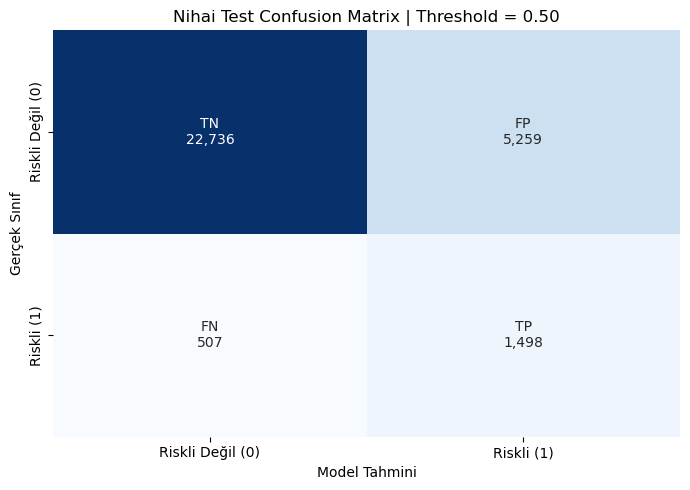

Doğru sınıflandırılan risksiz müşteri (TN): 22,736
Yanlış riskli işaretlenen müşteri (FP): 5,259
Kaçırılan riskli müşteri (FN): 507
Doğru tespit edilen riskli müşteri (TP): 1,498
False Positive Rate (FPR): %18.79


In [76]:
# =============================================================================
# ADIM 4.7.4: NİHAİ TEST CONFUSION MATRIX
# =============================================================================

cm = confusion_matrix(y_test, test_pred)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=np.array([
        [f'TN\n{tn:,}', f'FP\n{fp:,}'],
        [f'FN\n{fn:,}', f'TP\n{tp:,}']
    ]),
    fmt='',
    cmap='Blues',
    cbar=False,
    xticklabels=['Riskli Değil (0)', 'Riskli (1)'],
    yticklabels=['Riskli Değil (0)', 'Riskli (1)']
)

plt.title(f'Nihai Test Confusion Matrix | Threshold = {final_threshold:.2f}')
plt.xlabel('Model Tahmini')
plt.ylabel('Gerçek Sınıf')
plt.tight_layout()
plt.show()

print(f"Doğru sınıflandırılan risksiz müşteri (TN): {tn:,}")
print(f"Yanlış riskli işaretlenen müşteri (FP): {fp:,}")
print(f"Kaçırılan riskli müşteri (FN): {fn:,}")
print(f"Doğru tespit edilen riskli müşteri (TP): {tp:,}")
print(f"False Positive Rate (FPR): %{fp / (fp + tn) * 100:.2f}")

#### ANALİST YORUMU 

0.50 karar eşiğinde model, test setindeki 2.005 gerçek riskli müşterinin 1.498’ini doğru tespit etmiş, 507’sini ise kaçırmıştır (Recall: %74,71). Riskli olmayan 27.995 müşterinin 5.259’u yanlışlıkla riskli olarak işaretlenmiştir (FPR: %18,79).

Modelin riskli olarak sınıflandırdığı 6.757 müşterinin 1.498’i gerçekten riskli sınıftadır (Precision: %22,17). Bu sonuçlar, mevcut karar eşiğinde riskli müşterilerin önemli bir bölümünün tespit edildiğini ancak yanlış pozitif sınıflandırmaların da dikkate değer düzeyde olduğunu göstermektedir.

Nihai karar eşiği, gerçek uygulamada yanlış pozitif ve yanlış negatif kararların maliyetleri ile kurumun risk iştahı dikkate alınarak belirlenmelidir.

## 4.8. Tek Müşteri Risk Tahmini

Bu bölümde, eğitilmiş şampiyon modelin yeni bir müşteri için tahmin üretme süreci örneklendirilmektedir. Müşterinin ham bilgileri Pipeline'a aktarılır; veri düzeltme, eksik değer ikamesi, özellik türetme ve ölçekleme adımları eğitim verisinden öğrenilmiş parametrelerle otomatik olarak uygulanır.

Modelin ürettiği risk skoru, geliştirme aşamasında belirlenen 0.50 çalışma eşiğiyle karşılaştırılarak sınıf tahmini oluşturulur. Bu çıktı, kalibre edilmiş temerrüt olasılığı veya doğrudan kredi onay/ret kararı olarak değerlendirilmez.

In [77]:
# =============================================================================
# ADIM 4.8.1: TEK MÜŞTERİ RİSK TAHMİNİ
# =============================================================================

# Eğitim/test setinden bağımsız, temsili müşteri bilgileri
customer_data = {
    'RevolvingUtilizationOfUnsecuredLines': 0.65,
    'age': 42,
    'NumberOfTime30-59DaysPastDueNotWorse': 1,
    'DebtRatio': 0.45,
    'MonthlyIncome': 6500,
    'NumberOfOpenCreditLinesAndLoans': 7,
    'NumberOfTimes90DaysLate': 0,
    'NumberRealEstateLoansOrLines': 1,
    'NumberOfTime60-89DaysPastDueNotWorse': 0,
    'NumberOfDependents': 2
}

# Eğitimdeki ham özellik sırasını koru
customer_df = pd.DataFrame([customer_data])[X.columns]

# Eğitilmiş Pipeline ile tahmin
risk_score = champion_model.predict_proba(customer_df)[0, 1]
risk_class = int(risk_score >= final_threshold)

# Müşteri bilgilerini dikey tabloda göster
print("Müşteri Bilgileri:")
display(customer_df.T.rename(columns={0: 'Değer'}))

print(f"\nModel Risk Skoru: {risk_score:.4f}")
print(f"Çalışma Karar Eşiği: {final_threshold:.2f}")
print(f"Sınıf Tahmini: {'Riskli (1)' if risk_class else 'Riskli Değil (0)'}")

Müşteri Bilgileri:


,Değer
RevolvingUtilizationOfUnsecuredLines,0.65
age,42.00
NumberOfTime30-59DaysPastDueNotWorse,1.00
DebtRatio,0.45
MonthlyIncome,6500.00
NumberOfOpenCreditLinesAndLoans,7.00
NumberOfTimes90DaysLate,0.00
NumberRealEstateLoansOrLines,1.00
NumberOfTime60-89DaysPastDueNotWorse,0.00
NumberOfDependents,2.00



Model Risk Skoru: 0.6307
Çalışma Karar Eşiği: 0.50
Sınıf Tahmini: Riskli (1)


#### ANALİST YORUMU 

Temsili müşteri için hesaplanan risk skoru, belirlenen çalışma eşiğine göre değerlendirilerek sınıf tahmini oluşturulmuştur. Bu örnek, geliştirilen modelin yeni müşteri bilgileri üzerinden tahmin üretebildiğini göstermektedir.

## 5. Sonuç ve Genel Değerlendirme

Bu çalışmada, müşterilerin önümüzdeki iki yıl içerisinde 90 gün ve üzeri gecikmeye düşme durumunu tahmin etmek amacıyla uçtan uca bir kredi riski sınıflandırma modeli geliştirilmiştir. Veri inceleme, anomali yönetimi, özellik mühendisliği, model karşılaştırması ve karar eşiği analizi aşamaları yalnızca geliştirme verisi üzerinde yürütülmüş; başlangıçta ayrılan %20'lik test seti nihai değerlendirmeye kadar izole edilmiştir.

Logistic Regression, Random Forest, XGBoost ve LightGBM modelleri 5-Fold Stratified Cross-Validation ile karşılaştırılmıştır. LightGBM daha yüksek tahmin performansı sunmasına rağmen Logistic Regression, açıklanabilirlik önceliği doğrultusunda şampiyon model olarak seçilmiştir.

Şampiyon model, bağımsız test setinde 0.8606 ROC-AUC, 0.7212 Gini ve 0.3783 PR-AUC (Average Precision) değerlerine ulaşmıştır. Sabit 0.50 karar eşiğinde %74.71 Recall ve %22.17 Precision elde edilmiştir. Test sonuçlarının CV ortalamalarıyla tutarlı olması, ayrılan test örnekleminde belirgin bir performans kaybı görülmediğini ortaya koymuştur.

Karar eşiği analizi, riskli müşterileri daha yüksek oranda tespit etmek ile riskli olmayan müşterileri yanlış sınıflandırmak arasındaki değiş tokuşu somutlaştırmıştır. Bu çalışmada 0.50 çalışma eşiği kullanılmış olup gerçek uygulamada nihai eşik, kurumun risk iştahı ve yanlış sınıflandırma maliyetleri doğrultusunda belirlenmelidir.

Modelin ürettiği skorlar kalibre edilmiş temerrüt olasılığı olarak değerlendirilmemelidir. Gerçek kullanım öncesinde olasılık kalibrasyonu, farklı dönemlerde performans ve veri dağılımı takibi ile operasyonel doğrulama çalışmaları yapılmalıdır.